# Imports


In [3]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker


import numpy as np
import pandas as pd

import seaborn as sns
import torch

import re
from itertools import product
from lib.fuse_config import FuseConfig
sns.set_style("whitegrid")
DPI= 1000

do_save = True

## Helpers


In [4]:
## already adds the '<report>/assets/' five the rest
def savefig(path_rest: str, force_save:bool = False, g= None):

  if path_rest[-4:] != ".png":
    path_rest += ".png"

  if g is not None:
    g.tight_layout()
    g.savefig(f"/home/kup/Desktop/code/fyp-report/assets/{path_rest}", format="png", dpi=DPI)
    return 
  
  if force_save or do_save:
    plt.tight_layout()
    plt.savefig(f"/home/kup/Desktop/code/fyp-report/assets/{path_rest}", format="png", dpi=DPI)
    return
  


In [5]:
def combine_multi_file_rep(cfgs: list[FuseConfig], folder: str, file: str, format_name: str ):
  df_avgs = []
  df_alls = []

  for rep in range(3):
    for fuse_config  in cfgs:
      name = format_name.format(file = file, fuse_config = fuse_config, rep = rep)
      
      avg = pd.read_csv(f"{folder}/{name}.csv")
      all = pd.read_csv(f"{folder}/ALL{name}.csv")

      all = all[~all["error"]]
      avg = avg[~avg["error"]]
      df_avgs.append(avg)
      df_alls.append(all)
  all_df = pd.concat(df_alls, ignore_index=True)
  avg_df = pd.concat(df_avgs, ignore_index=True)


  all_df.to_csv(f"{folder}/ALL{file}.csv", )
  avg_df.to_csv(f"{folder}/{file}.csv")

def combine_multi_file_seed(
  cfgs: list[FuseConfig], 
  folder: str, 
  file: str, 
  format_name: str, 
  seeds = [3790,1901,4248,6689,7653]
):
  df_avgs = []
  df_alls = []
    

  for seed in seeds:
    for fuse_config  in cfgs:
      name = format_name.format(file = file, fuse_config = fuse_config, seed = seed)
      
      avg = pd.read_csv(f"{folder}/{name}.csv")
      all = pd.read_csv(f"{folder}/ALL{name}.csv")

      all = all[~all["error"]]
      avg = avg[~avg["error"]]
      df_avgs.append(avg)
      df_alls.append(all)
      
  all_df = pd.concat(df_alls, ignore_index=True)
  avg_df = pd.concat(df_avgs, ignore_index=True)


  all_df.to_csv(f"{folder}/ALL{file}.csv", )
  avg_df.to_csv(f"{folder}/{file}.csv")


In [6]:
def final_and_min_melter(df) -> tuple[pd.DataFrame, pd.DataFrame]:
  df_long = df.melt(
      id_vars=['epochs', 'cam_type', 'config', 'seed'],
      value_vars=[
        'avg_control_final_distance',
        'avg_test_final_distance',
        'avg_control_min_distance',
        'avg_test_min_distance',
      ],
      var_name='condition',
      value_name='distance'
  )
  df_long["condition"] = df_long["condition"].map({
    "avg_control_final_distance": "(Control) Final Distance", 
    "avg_test_final_distance": "(Test) Final Distance",
    "avg_control_min_distance": "(Control) Minimum Distance", 
    "avg_test_min_distance": "(Test) Minimum Distance",
  })


  return df_long[df_long["condition"].str.contains("Final")], df_long[df_long["condition"].str.contains("Minimum")]


def done_count_melter(df) -> pd.DataFrame:
  df_long = df.melt(
      id_vars=['epochs', 'cam_type', 'config', 'seed'],
      value_vars=[
        "control_done_count", 
        "test_done_count", 
      ],
      var_name='condition',
      value_name='done_count'
  )
  df_long["condition"] = df_long["condition"].map({
    "control_done_count": "(Control)",
    "test_done_count": "(Test)"
  })


  return df_long

In [7]:
def final_and_min_melter2(df: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame]:
  # df.groupby([
  #   "seed", "config", "demo_idx", "cam_type", "epochs"
  # ])
  df_long = df.melt(
      id_vars=['epochs', 'cam_type', 'config', 'seed'],
      value_vars=[
        'control_final_distance',
        'test_final_distance',
        'control_min_distance',
        'test_min_distance',
      ],
      var_name='condition',
      value_name='distance'
  )
  df_long["condition"] = df_long["condition"].map({
    "control_final_distance": "(Control) final", 
    "test_final_distance": "(Test) final",
    "control_min_distance": "(Control) min", 
    "test_min_distance": "(Test) min",
  })
  return (df_long[df_long["condition"].str.contains("final")], 
          df_long[df_long["condition"].str.contains("min")])

def done_count_melter2(df: pd.DataFrame) -> pd.DataFrame:
  df_long = df.melt(
    id_vars=['epochs', 'cam_type', 'config', 'seed'],
    value_vars=[
      "is_control_done", 
      "is_test_done", 
    ],
    var_name='condition',
    value_name='done_count'
  )
  df_long["condition"] = df_long["condition"].map({
    "is_control_done": "(Control)",
    "is_test_done": "(Test)"
  })


  return df_long

In [8]:
def all_final_and_min_melter(df: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame]:
  # df.groupby([
  #   "seed", "config", "demo_idx", "cam_type", "epochs"
  # ])
  df_long = df.melt(
      id_vars=['epochs', 'cam_type', 'config', 'seed', "demo_idx"],
      value_vars=[
        'control_final_distance',
        'test_final_distance',
        'control_min_distance',
        'test_min_distance',
      ],
      var_name='condition',
      value_name='distance'
  )
  df_long["condition"] = df_long["condition"].map({
    "control_final_distance": "(Control) final", 
    "test_final_distance": "(Test) final",
    "control_min_distance": "(Control) min", 
    "test_min_distance": "(Test) min",
  })
  return (df_long[df_long["condition"].str.contains("final")], 
          df_long[df_long["condition"].str.contains("min")])

def all_done_count_melter(df: pd.DataFrame) -> pd.DataFrame:
  df_long = df.melt(
    id_vars=['epochs', 'cam_type', 'config', 'seed', 'demo_idx'],
    value_vars=[
      "is_control_done", 
      "is_test_done", 
    ],
    var_name='condition',
    value_name='done_count'
  )
  df_long["condition"] = df_long["condition"].map({
    "is_control_done": "(Control)",
    "is_test_done": "(Test)"
  })


  return df_long

# Fusing Policy Runs


## First big run (set dist demos) 
4/10 small demos were not visible for some reason, and 2/10 wer really small

In [ ]:
comp_all = pd.read_csv("ZZbig-run-1/ALLvs_random-ns.csv")
comp_avg = pd.read_csv("ZZbig-run-1/vs_random-ns.csv")


### plotting the non film

In [ ]:
cfgs = [
  FuseConfig.WDLR,
  FuseConfig.WLR_D,
  FuseConfig.DEPTH_FEATS_GATED,
  FuseConfig.DEPTH_FEATS_ATTN,
  FuseConfig.WD_LR,
  FuseConfig.WD_LR_ATTN,
]

df_1_all = comp_all[comp_all["config"].isin(map(str, cfgs))]
df_1_avg = comp_avg[comp_avg["config"].isin(map(str, cfgs))]


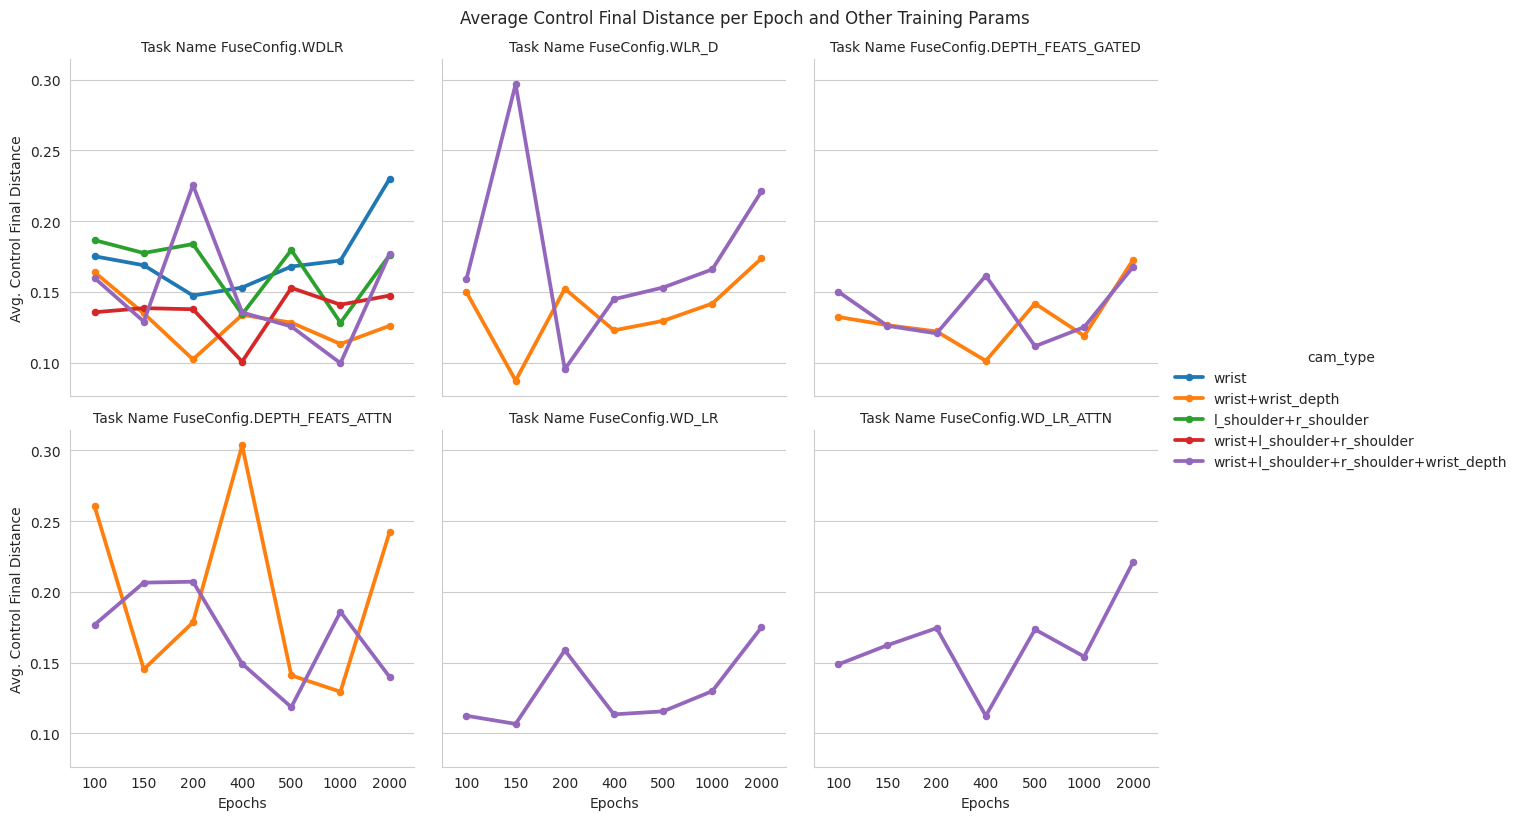

In [64]:
# Plot
g = sns.catplot(
    data=df_1_avg,
    x='epochs',
    y='avg_control_final_distance',
    hue='cam_type',
    col='config',
    col_wrap=3,
    kind="point",
    errorbar=None,
    markers=["."] * 10,
    palette="tab10",
    height=4,
    aspect=1,
)

g.set_titles("Task Name {col_name}")
g.set_axis_labels("Epochs", "Avg. Control Final Distance")
g.figure.suptitle("Average Control Final Distance per Epoch and Other Training Params", y=1.02)#
# savefig(f"cam-comb/reach-obs/Z-ro_random-success.png", g = g)
plt.show()


In [91]:
df_1avg_long_final, df_1avg_long_min = final_and_min_melter(df_1_avg)

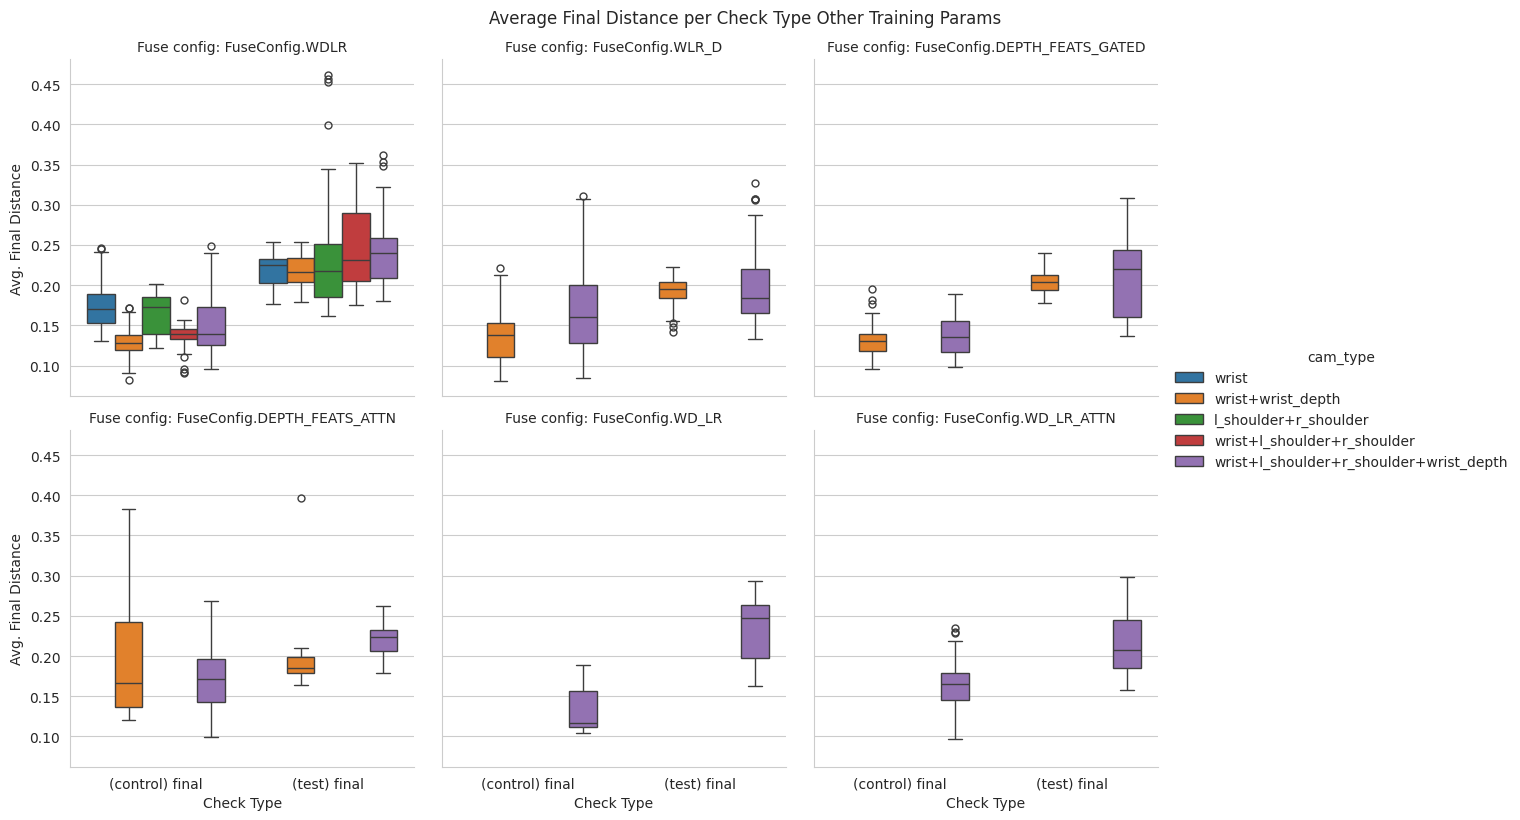

In [92]:
# Plot
g = sns.catplot(
    data=df_1avg_long_final,
    x='condition',
    y='distance',
    hue='cam_type',
    col="config", 
    # row='epochs',
    col_wrap=3,
    kind="box",
    errorbar=None,
    # markers=["."] * 10,
    palette="tab10",
    height=4,
    aspect=1,
)

# g.set_titles("Epochs: {row_name}, \n Fuse config: {col_name}")
g.set_titles("Fuse config: {col_name}")
g.set_axis_labels("Check Type", "Avg. Final Distance")
g.figure.suptitle("Average Final Distance per Check Type Other Training Params", y=1.02)#
# savefig(f"cam-comb/reach-obs/Z-ro_random-success.png", g = g)
plt.show()


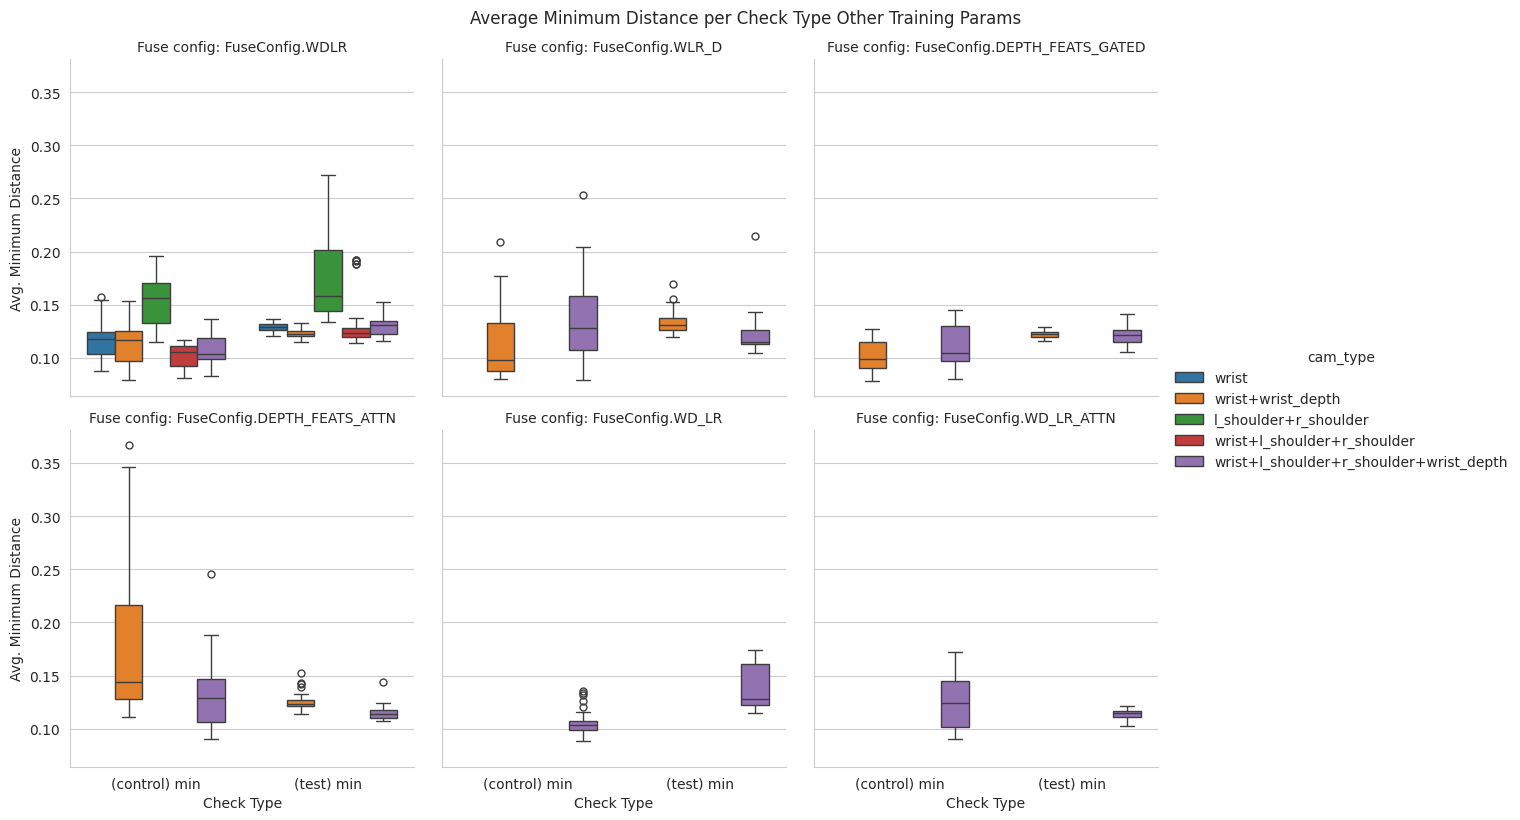

In [93]:
# Plot
g = sns.catplot(
    data=df_1avg_long_min,
    x='condition',
    y='distance',
    hue='cam_type',
    col="config", 
    # row='epochs',
    col_wrap=3,
    kind="box",
    errorbar=None,
    # markers=["."] * 10,
    palette="tab10",
    height=4,
    aspect=1,
)

# g.set_titles("Epochs: {row_name}, \n Fuse config: {col_name}")
g.set_titles("Fuse config: {col_name}")
g.set_axis_labels("Check Type", "Avg. Minimum Distance")
g.figure.suptitle("Average Minimum Distance per Check Type Other Training Params", y=1.02)#
# savefig(f"cam-comb/reach-obs/Z-ro_random-success.png", g = g)
plt.show()


### plotting the film

In [ ]:
cfgs  =[ 
  FuseConfig.Wfilm_D,
  FuseConfig.W_Dfilm,
  FuseConfig.Wfilm_Dfilm,
]
df_film_all = comp_all[comp_all["config"].isin(map(str, cfgs))]
df_film_avg = comp_avg[comp_avg["config"].isin(map(str, cfgs))]
df_film_avg

,Unnamed: 0.1,Unnamed: 0,rep,config,error,task_name,cam_type,epochs,control_done_count,test_done_count,avg_control_final_distance,avg_control_min_distance,avg_test_min_distance,avg_test_final_distance
91,91,1,0,FuseConfig.Wfilm_D,False,Vision_Random,wrist+wrist_depth,100,0.0,0.0,0.280629,0.276401,0.152377,0.193636
92,92,6,0,FuseConfig.Wfilm_D,False,Vision_Random,wrist+wrist_depth,150,0.0,0.0,0.479325,0.371478,0.140643,0.204892
93,93,11,0,FuseConfig.Wfilm_D,False,Vision_Random,wrist+wrist_depth,200,0.0,0.0,0.348067,0.133032,0.141982,0.291147
94,94,16,0,FuseConfig.Wfilm_D,False,Vision_Random,wrist+wrist_depth,400,0.0,0.0,0.365635,0.360892,0.201903,0.203407
95,95,21,0,FuseConfig.Wfilm_D,False,Vision_Random,wrist+wrist_depth,500,0.0,0.0,0.156872,0.126121,0.120530,0.195172
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
555,555,11,4,FuseConfig.Wfilm_Dfilm,False,Vision_Random,wrist+wrist_depth,200,0.0,0.0,0.292095,0.268518,0.124259,0.179419
556,556,16,4,FuseConfig.Wfilm_Dfilm,False,Vision_Random,wrist+wrist_depth,400,3.0,0.0,0.150535,0.127302,0.123981,0.224422
557,557,21,4,FuseConfig.Wfilm_Dfilm,False,Vision_Random,wrist+wrist_depth,500,1.0,0.0,0.182567,0.174499,0.127654,0.224672
558,558,26,4,FuseConfig.Wfilm_Dfilm,False,Vision_Random,wrist+wrist_depth,1000,0.0,0.0,0.189146,0.175817,0.126348,0.190686


## Big Run 2
the big boys 4 way ATTN and film are ran here

In [ ]:
comp_all = pd.read_csv("ZZbig-run-2/ALLvs_random-ns.csv")
comp_avg = pd.read_csv("ZZbig-run-2/vs_random-ns.csv")

In [ ]:
cfgs = [
  FuseConfig.W_D_L_R_FILM,
  FuseConfig.W_D_L_R_ATTN,
]

df_film_all = comp_all[comp_all["config"].isin(map(str, cfgs))]
df_film_avg = comp_avg[comp_avg["config"].isin(map(str, cfgs))]
df_film_avg_long_final, df_film_avg_long_min = final_and_min_melter(df_film_avg)
df_film_avg_dones = done_count_melter(df_film_avg)

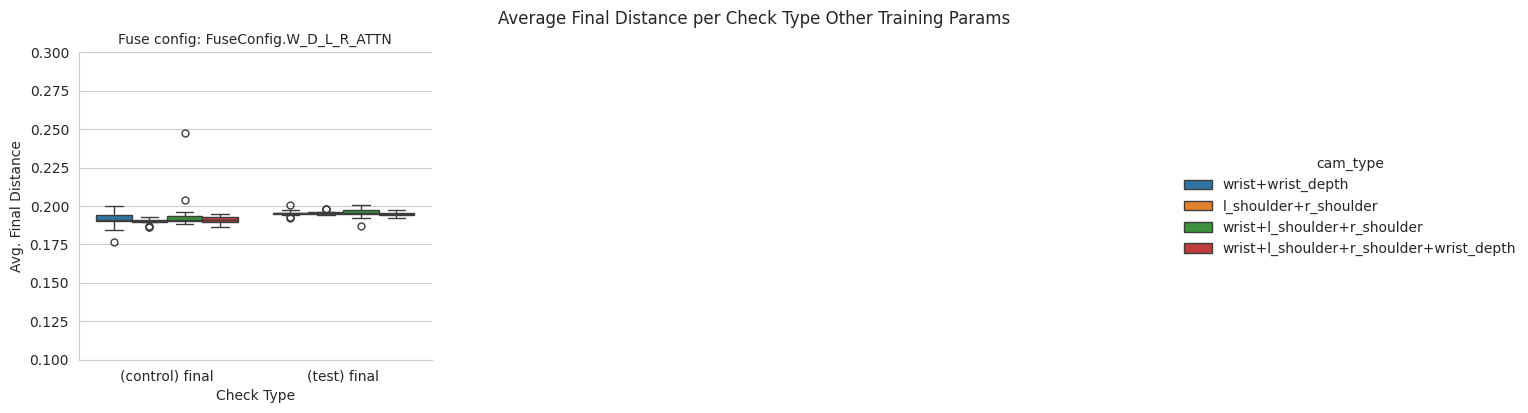

In [102]:
# Plot
g = sns.catplot(
    data=df_film_avg_long_final,
    x='condition',
    y='distance',
    hue='cam_type',
    col="config", 
    # row='epochs',
    col_wrap=3,
    kind="box",
    errorbar=None,
    # markers=["."] * 10,
    palette="tab10",
    height=4,
    aspect=1,
)

# g.set_titles("Epochs: {row_name}, \n Fuse config: {col_name}")
g.set_titles("Fuse config: {col_name}")
g.set_axis_labels("Check Type", "Avg. Final Distance")
g.figure.suptitle("Average Final Distance per Check Type Other Training Params", y=1.02)#
g.set(ylim=(0.1, 0.3))
# savefig(f"cam-comb/reach-obs/Z-ro_random-success.png", g = g)
plt.show()


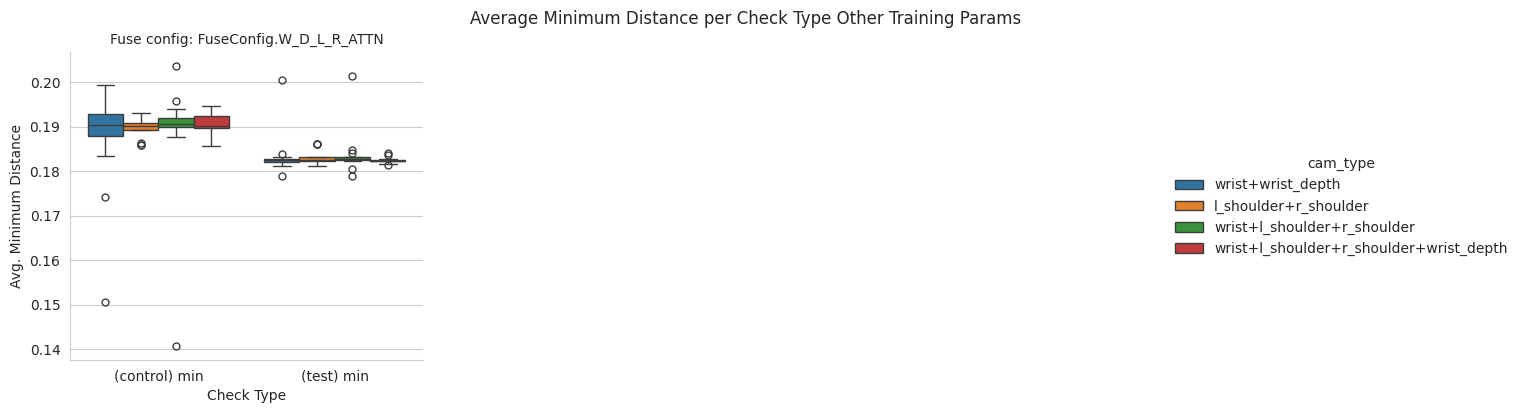

In [103]:
# Plot
g = sns.catplot(
    data=df_film_avg_long_min,
    x='condition',
    y='distance',
    hue='cam_type',
    col="config", 
    # row='epochs',
    col_wrap=3,
    kind="box",
    errorbar=None,
    # markers=["."] * 10,
    palette="tab10",
    height=4,
    aspect=1,
)

# g.set_titles("Epochs: {row_name}, \n Fuse config: {col_name}")
g.set_titles("Fuse config: {col_name}")
g.set_axis_labels("Check Type", "Avg. Minimum Distance")
g.figure.suptitle("Average Minimum Distance per Check Type Other Training Params", y=1.02)#
# savefig(f"cam-comb/reach-obs/Z-ro_random-success.png", g = g)
plt.show()


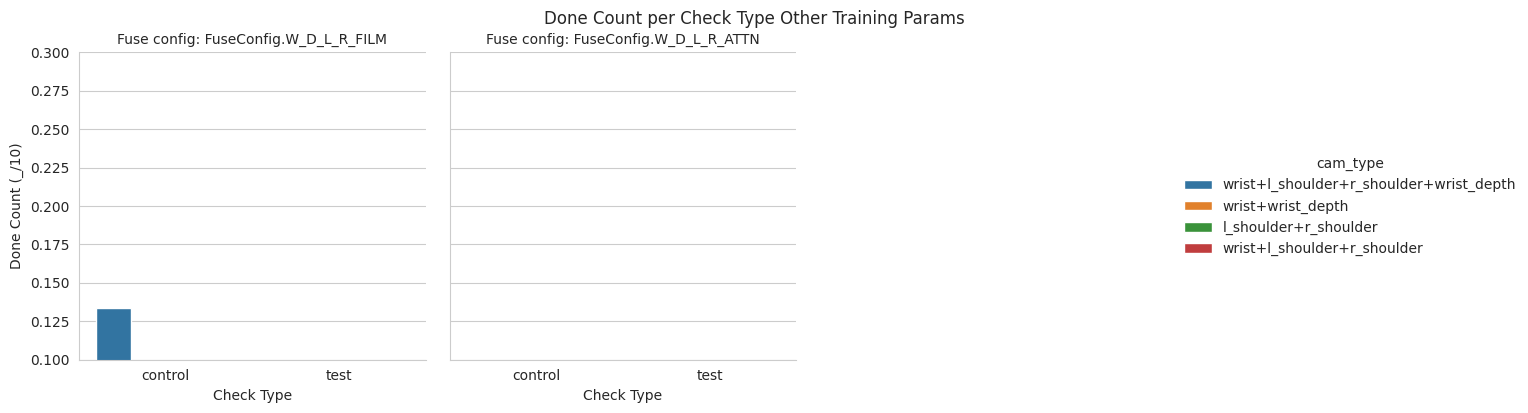

In [107]:
# Plot
g = sns.catplot(
    data=df_film_avg_dones,
    x='condition',
    y='done_count',
    hue='cam_type',
    col="config", 
    # row='epochs',
    col_wrap=3,
    kind="bar",
    errorbar=None,
    # markers=["."] * 10,
    palette="tab10",
    height=4,
    aspect=1,
)

# g.set_titles("Epochs: {row_name}, \n Fuse config: {col_name}")
g.set_titles("Fuse config: {col_name}")
g.set_axis_labels("Check Type", "Done Count (_/10)")
g.figure.suptitle("Done Count per Check Type Other Training Params", y=1.02)#
g.set(ylim=(0.1, 0.3))
# savefig(f"cam-comb/reach-obs/Z-ro_random-success.png", g = g)
plt.show()


## Films Comparison

### normal then small

In [ ]:
configs = [
  FuseConfig.WDLR,
  FuseConfig.Wfilm_D,
  FuseConfig.Wfilm_D,
  FuseConfig.W_Dfilm,
  FuseConfig.Wfilm_Dfilm,
  FuseConfig.Wfilm_D_LATE,
  FuseConfig.W_Dfilm_LATE,
  FuseConfig.Wfilm_Dfilm_LATE,
]

comp_all = pd.read_csv("ZZ-films-wd/ALLvs_random-sn.csv")
comp_avg = pd.read_csv("ZZ-films-wd/vs_random-sn.csv")

base = df_base_avg[df_base_avg["cam_type"] == "wrist+wrist_depth"]
comp_avg = pd.concat([base, comp_avg], ignore_index=True)

df_avg_long_final, df_avg_long_min = final_and_min_melter(comp_avg)
# df_avg_long_final[df_avg_long_final["epochs"] == 400]

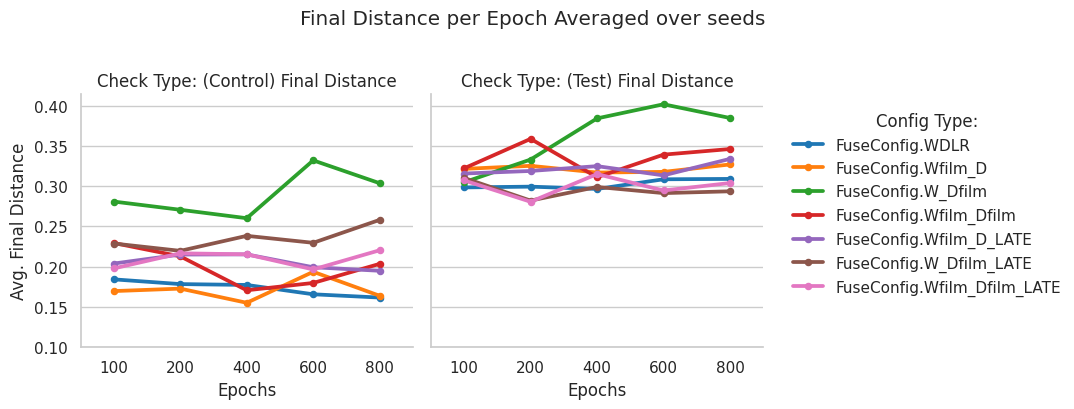

In [ ]:
sns.set_theme(style='whitegrid', palette='Set1')

g = sns.catplot(
    data=df_avg_long_final,
    x='epochs',
    y='distance',
    hue='config',
    col='condition',
    # row='seed',
    col_wrap=2,
    kind="point",
    errorbar=None,
    markers=["."] * 10,
    palette="tab10",
    height=4,
    aspect=1,
    # legend = None
)

g.set_titles("Check Type: {col_name}")
g.set_axis_labels("Epochs", "Avg. Final Distance")
g.figure.suptitle("Final Distance per Epoch Averaged over seeds", y=1.02)#
g.set(ylim=(0.1))
g._legend.set_title("Config Type:")
savefig(f"evaluation/film/film-grasp-final.png", g = g)
plt.show()


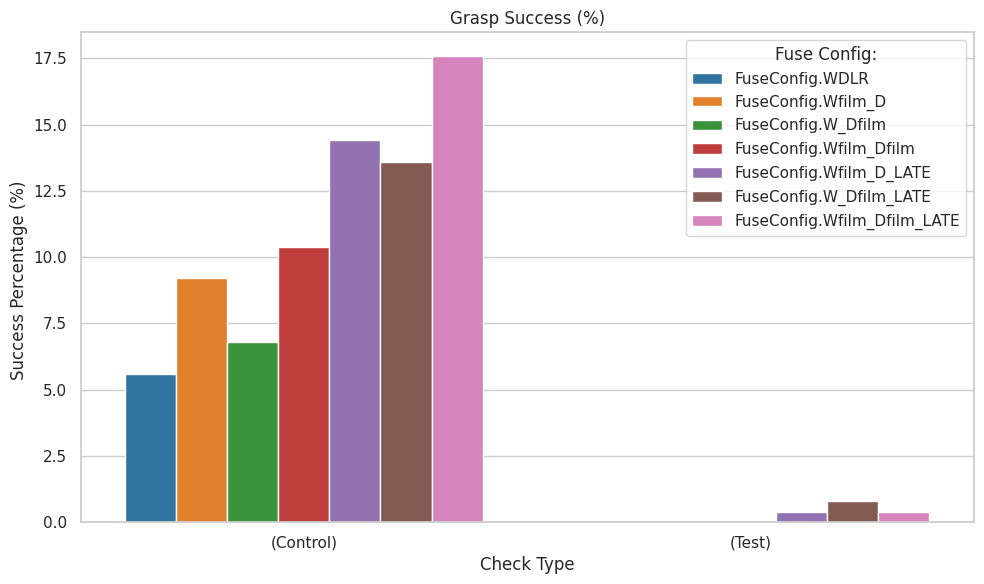

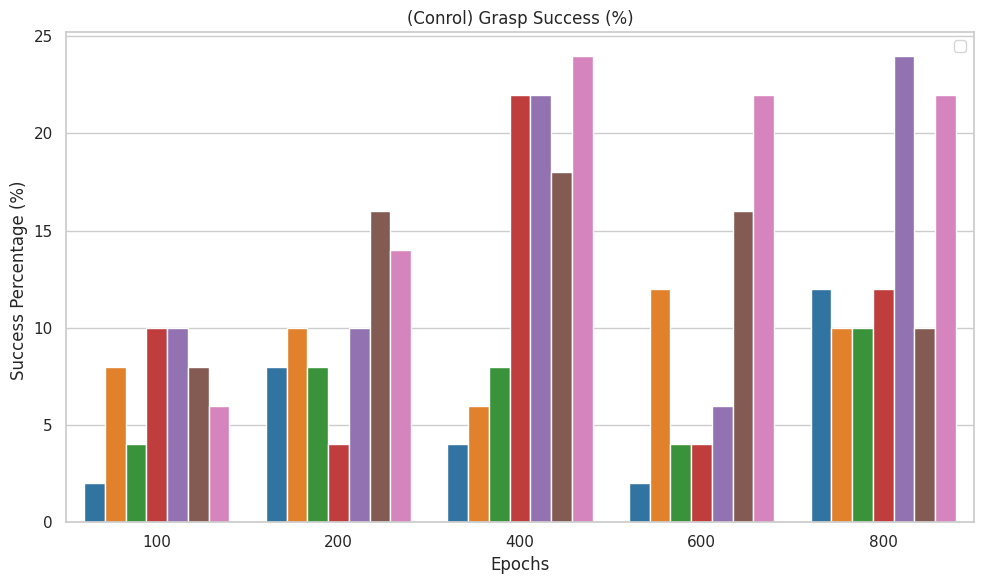

In [496]:
df_avg_dones = done_count_melter(comp_avg)
df_avg_dones["done_pct"] = df_avg_dones["done_count"].apply(lambda dc: dc * 10)

plt.figure(figsize=(10, 6))
sns.set_theme(style='whitegrid', palette='Set1')
sns.barplot(data=df_avg_dones, y='done_pct', x="condition", hue='config', palette='tab10', errorbar=None)
plt.title(f'Grasp Success (%)')
plt.legend(title="Fuse Config:")
plt.ylabel('Success Percentage (%) ')
plt.xlabel('Check Type')
savefig(f"evaluation/film/film-grasp-success.png")
plt.show()

plt.figure(figsize=(10, 6))
sns.set_theme(style='whitegrid', palette='Set1')
sns.barplot(data=df_avg_dones[df_avg_dones["condition"].str.contains("Control")], y='done_pct', x="epochs", hue='config', palette='tab10', errorbar=None)
plt.title(f'(Conrol) Grasp Success (%)')
plt.legend("")
plt.ylabel('Success Percentage (%) ')
plt.xlabel('Epochs')
savefig(f"evaluation/film/film-grasp-control-success-epochs.png")
plt.show()

/tmp/ipykernel_5659/2278962899.py:22: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title="Fuse Config:")


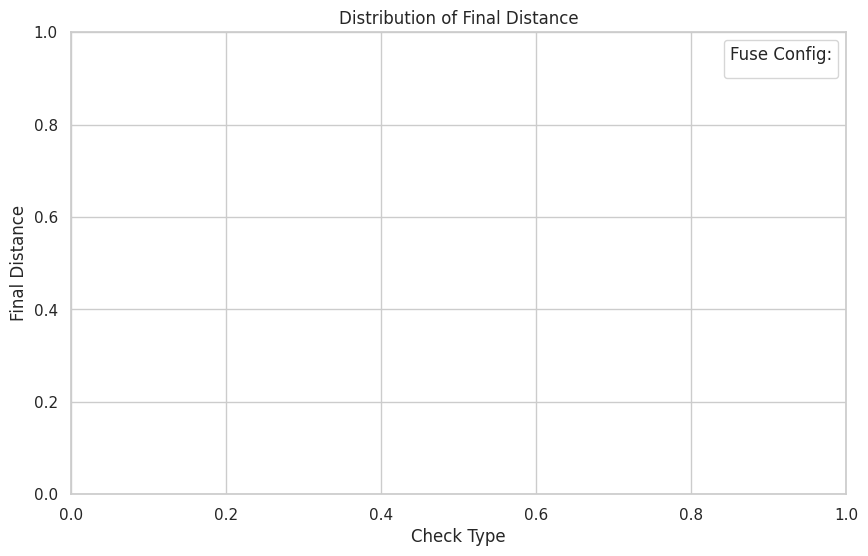

In [ ]:
# sns.lineplot(data=df_avg_long_final[df_avg_long_final["condition"].str.contains("control")], y='distance', x="epochs", hue='config', palette='tab10', errorbar= None)
# plt.title(f'(Control) Average Final Distance')
# plt.legend(title="Fuse Config:")
# plt.ylabel('Final Distance')
# plt.xlabel('Epochs')
# # savefig(f"evaluation/film/film-final-control.png", g = g)
# plt.show()

# sns.lineplot(data=df_avg_long_final[df_avg_long_final["condition"].str.contains("test")], y='distance', x="epochs", hue='config', palette='tab10', errorbar= None)
# plt.title(f'(Test) Average Final Distance')
# plt.legend(title="Fuse Config:")
# plt.ylabel('Final Distance')
# plt.xlabel('Epochs')
# # savefig(f"evaluation/film/film-final-control.png", g = g)
# plt.show()


plt.figure(figsize=(10, 6))
sns.set_theme(style='whitegrid', palette='Set1')
sns.barplot(data=df_avg_long_final[df_avg_long_final["condition"].str.contains("control")], y='distance', x="seed", hue='config', palette='tab10')
plt.title(f'Distribution of Final Distance')
plt.legend(title="Fuse Config:")
plt.ylabel('Final Distance')
plt.xlabel('Check Type')
# savefig(f"evaluation/film/film-control-final-per-seed.png", g = g)
plt.show()

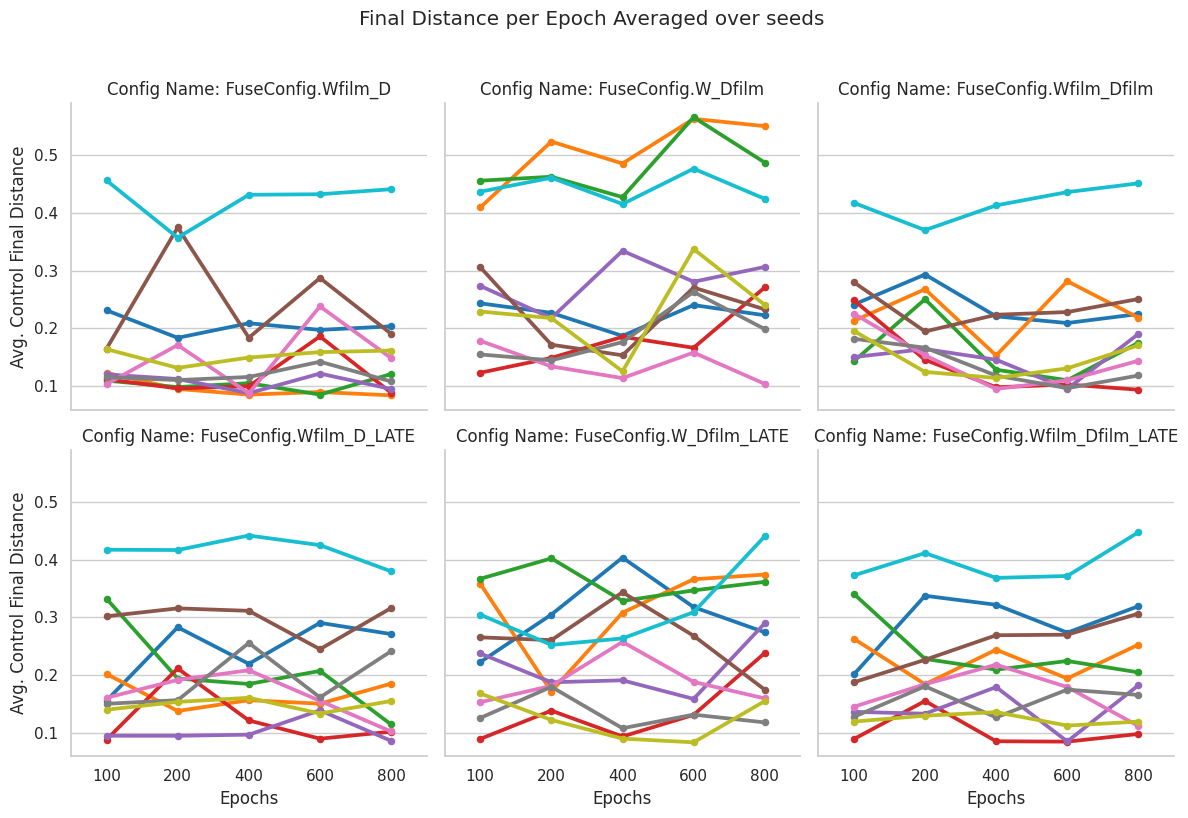

In [499]:
# Plot
g = sns.catplot(
    data=comp_all,
    x='epochs',
    y='control_final_distance',
    hue='demo_idx',
    col='config',
    # row='seed',
    col_wrap=3,
    kind="point",
    errorbar=None,
    markers=["."] * 10,
    palette="tab10",
    height=4,
    aspect=1,
    legend = None ## its just seed
)

g.set_titles("Config Name: {col_name}")
g.set_axis_labels("Epochs", "Avg. Control Final Distance")
g.figure.suptitle("Final Distance per Epoch Averaged over seeds", y=1.02)#
savefig(f"evaluation/film/Z-control-final-per-demo.png", g = g)
plt.show()


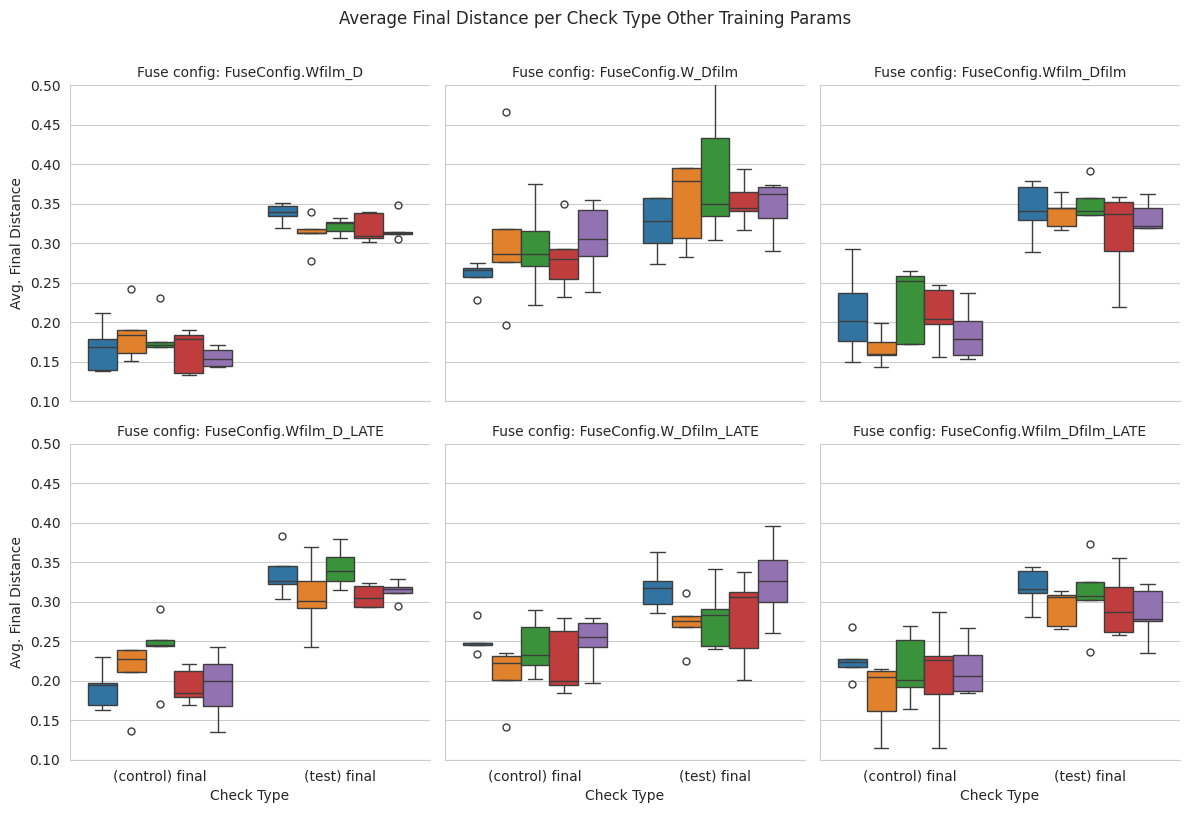

In [ ]:
# Plot
g = sns.catplot(
    data=df_avg_long_final,
    x='condition',
    y='distance',
    hue='seed',
    col="config", 
    # row='epochs',
    col_wrap=3,
    kind="box",
    errorbar=None,
    # markers=["."] * 10,
    palette="tab10",
    height=4,
    aspect=1,
    legend = None
)

# g.set_titles("Epochs: {row_name}, \n Fuse config: {col_name}")
g.set_titles("Fuse config: {col_name}")
g.set_axis_labels("Check Type", "Avg. Final Distance")
g.set(ylim=(0.1, 0.5))
g.figure.suptitle("Average Final Distance per Check Type Other Training Params", y=1.01)#
savefig(f"evaluation/film/Z-film-avg-final.png", g = g)
plt.show()


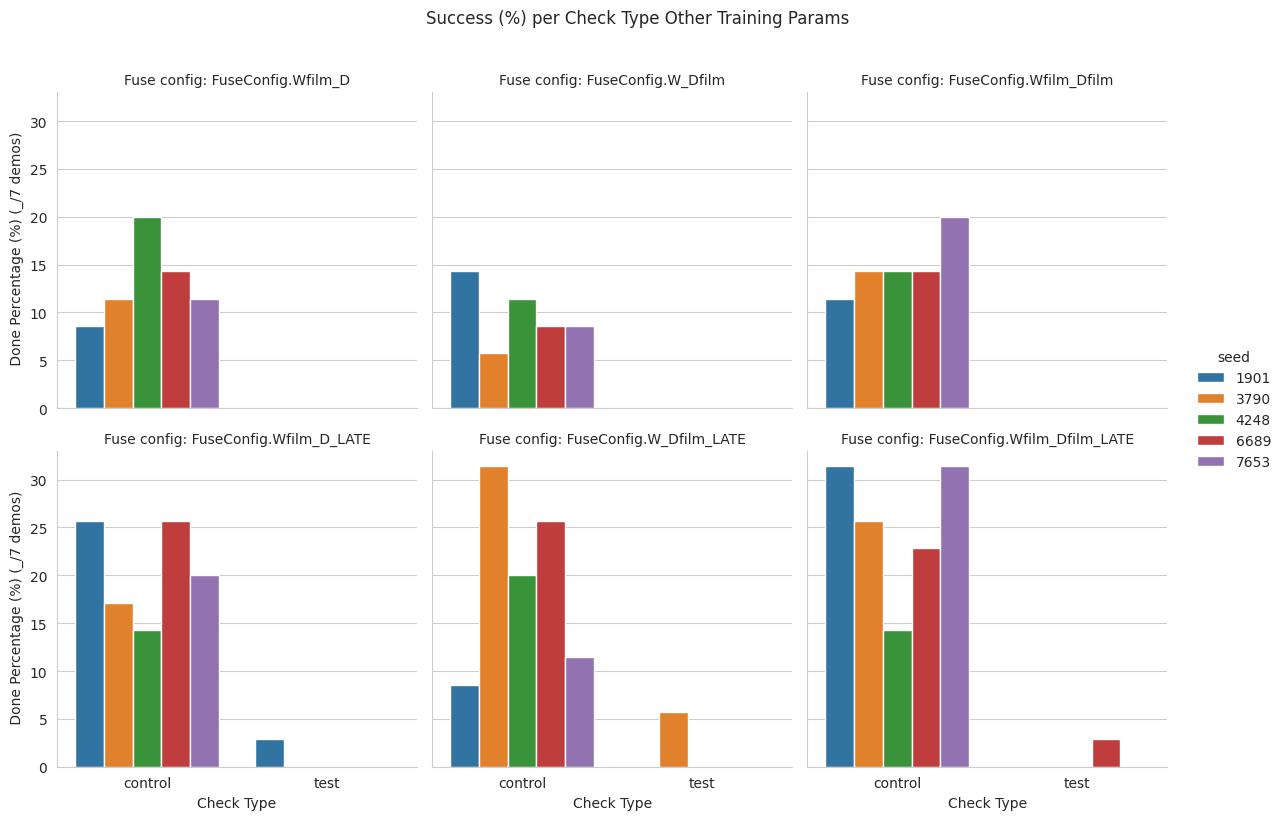

In [ ]:
##NOTE: presnet this in table form i think
df_avg_dones = done_count_melter(comp_avg)
df_avg_dones["done_pct"] = df_avg_dones["done_count"].apply(lambda dc: dc * 100 / 7)
# Plot
g = sns.catplot(
    data=df_avg_dones,#[df_avg_dones["condition"] == "control"],
    x='condition',
    y='done_pct',
    hue='seed',
    col="config", 
    # row='epochs',
    col_wrap=3,
    kind="bar",
    errorbar=None,
    # markers=["."] * 10,
    palette="tab10",
    height=4,
    aspect=1,
)

# g.set_titles("Epochs: {row_name}, \n Fuse config: {col_name}")
g.set_titles("Fuse config: {col_name}")
g.set_axis_labels("Check Type", " Done Percentage (%) ")
g.figure.suptitle("Success (%) per Check Type Other Training Params", y=1.02)#
savefig(f"evaluation/film/Z-film-success.png", g = g)
plt.show()


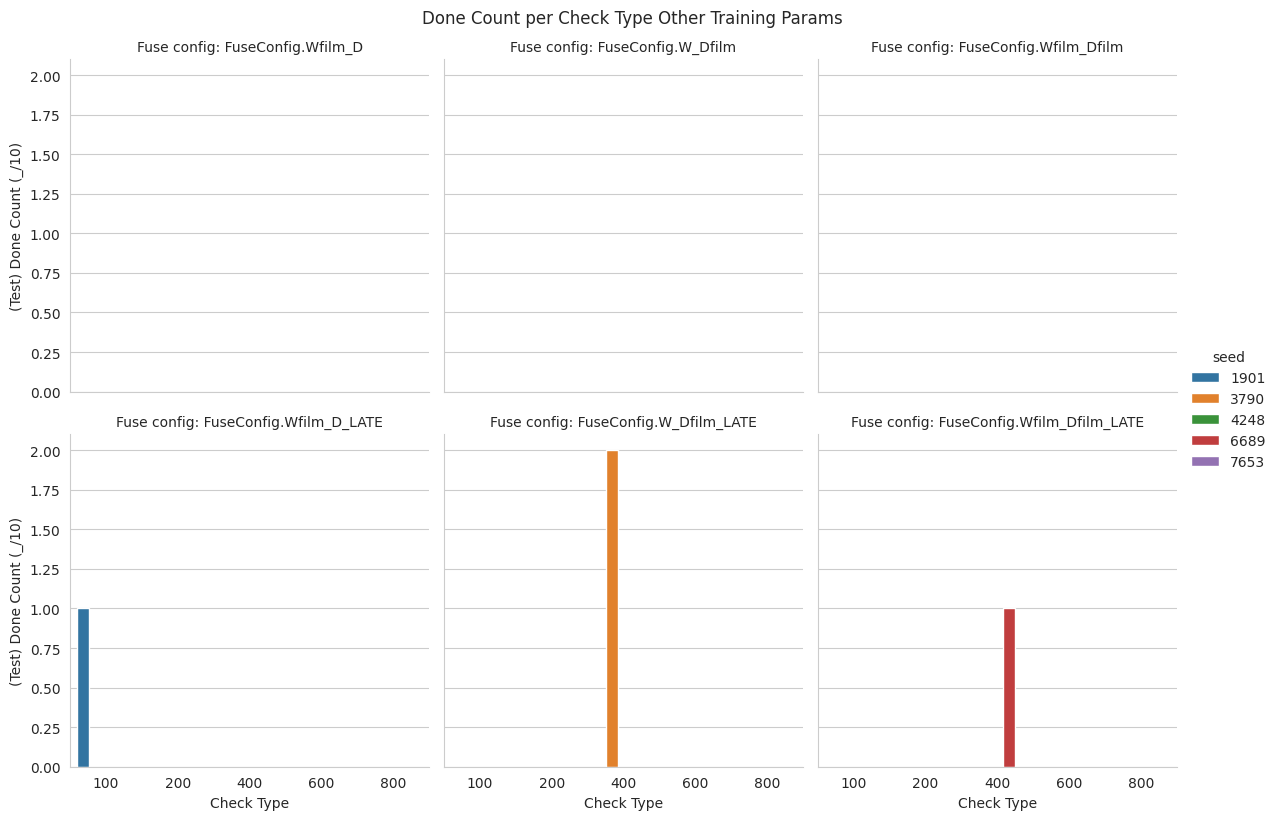

In [ ]:
df_avg_dones = done_count_melter(comp_avg)
# Plot
g = sns.catplot(
    data=df_avg_dones[df_avg_dones["condition"] == "test"],
    x='epochs',
    y='done_count',
    hue='seed',
    col="config", 
    # row='epochs',
    col_wrap=3,
    kind="bar",
    errorbar=None,
    # markers=["."] * 10,
    palette="tab10",
    height=4,
    aspect=1,
)

# g.set_titles("Epochs: {row_name}, \n Fuse config: {col_name}")
g.set_titles("Fuse config: {col_name}")
g.set_axis_labels("Check Type", "(Test) Done Count (_/10)")
g.figure.suptitle("Done Count per Check Type Other Training Params", y=1.02)#
# savefig(f"cam-comb/reach-obs/Z-ro_random-success.png", g = g)
plt.show()

##NOTE: mention this as a footnote somewhere

### small then normal

In [ ]:
take = [
  FuseConfig.WDLR,
  FuseConfig.Wfilm_D,
  FuseConfig.W_Dfilm,
  FuseConfig.Wfilm_Dfilm,
  FuseConfig.Wfilm_D_LATE,
  FuseConfig.W_Dfilm_LATE,
  FuseConfig.Wfilm_Dfilm_LATE,
]

comp_all = pd.read_csv("ZZ-small-then-normal/ALLvs_random-sn.csv")
df_film = comp_all[comp_all["config"].isin(map(str, take))]
df_film = df_film[df_film["cam_type"] == "wrist+wrist_depth"]
df_film = df_film[~df_film["demo_idx"].isin([0., 5., 6.])]
comp_avg = df_film.groupby([
  "seed", "config", "cam_type", "epochs" 
], sort = True
)[
  ["is_control_done",
  "is_test_done", 
  "control_final_distance",
  "test_final_distance",
  "control_min_distance",
  "test_min_distance",]
  ].mean().reset_index()

df_avg_long_final, df_avg_long_min = final_and_min_melter2(comp_avg)
df_avg_dones = done_count_melter2(comp_avg)
df_avg_dones["done_pct"] = df_avg_dones["done_count"].apply(lambda dc: float(dc) * 100) ##removed bad 3

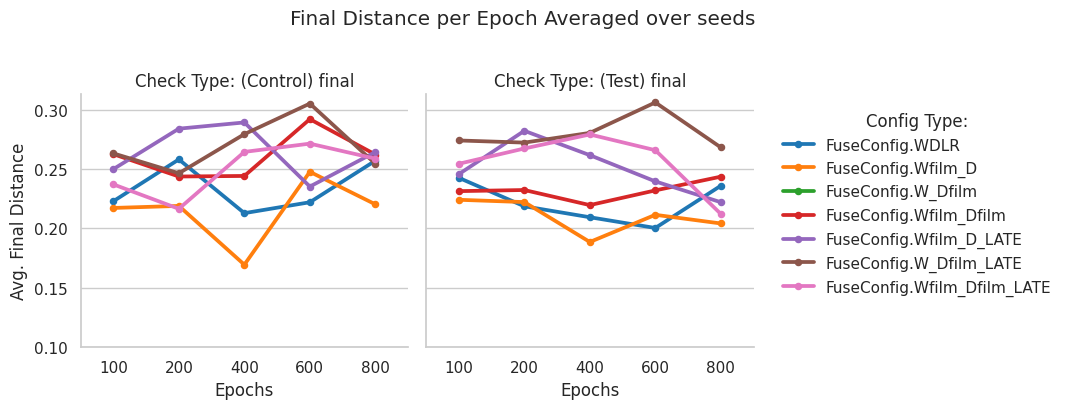

In [ ]:
sns.set_theme(style='whitegrid', palette='Set1')

g = sns.catplot(
    data=df_avg_long_final,
    x='epochs',
    y='distance',
    hue='config',
    hue_order=list(map(str, take)),
    col='condition',
    # row='seed',
    col_wrap=2,
    kind="point",
    errorbar=None,
    markers=["."] * 10,
    palette="tab10",
    height=4,
    aspect=1,
    # legend=map(str, take)
)

g.set_titles("Check Type: {col_name}")
g.set_axis_labels("Epochs", "Avg. Final Distance")
g.figure.suptitle("Final Distance per Epoch Averaged over seeds", y=1.02)#
g.set(ylim=(0.1))
g._legend.set_title("Config Type:")
savefig(f"evaluation/film/film-grasp-final-smaller.png", g = g)
plt.show()


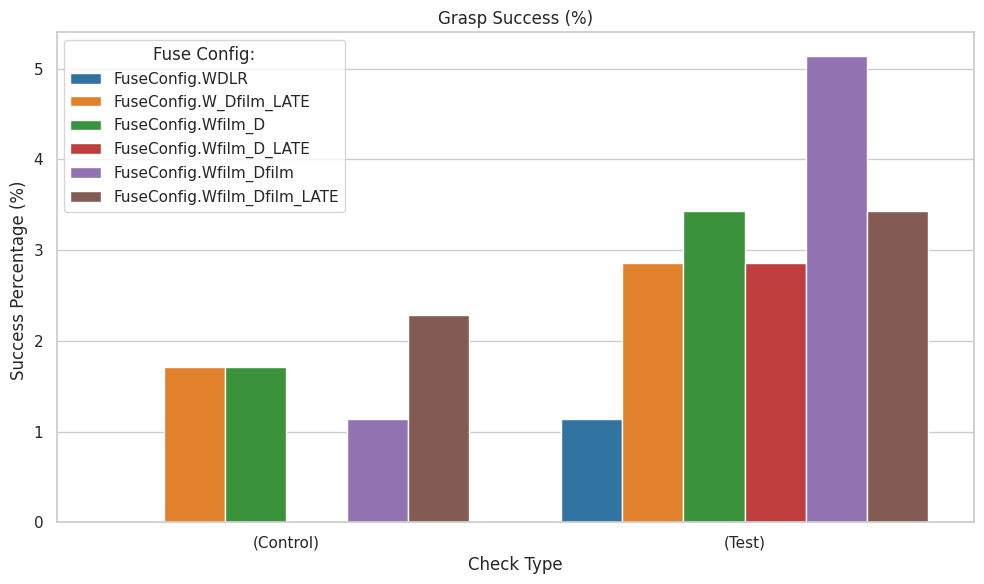

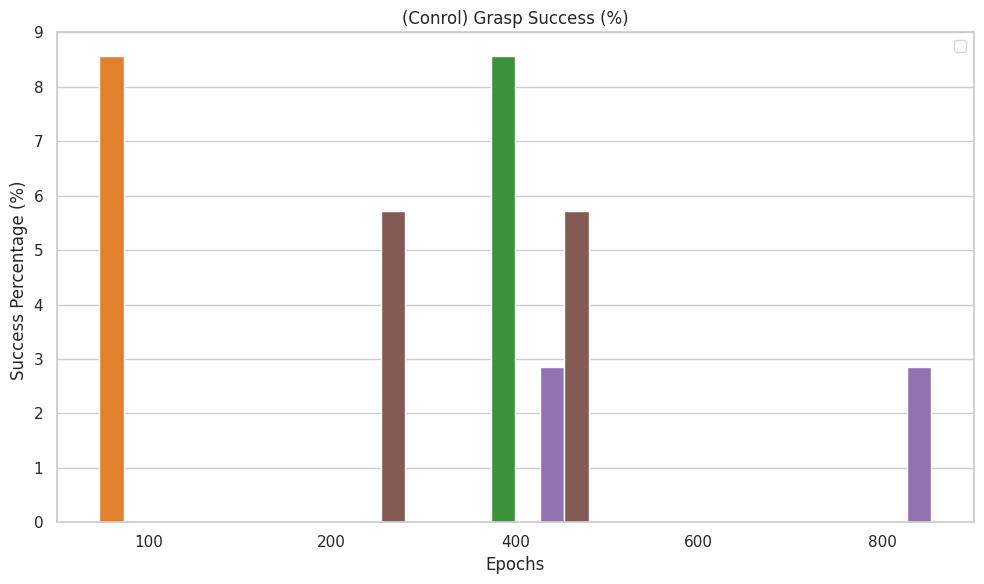

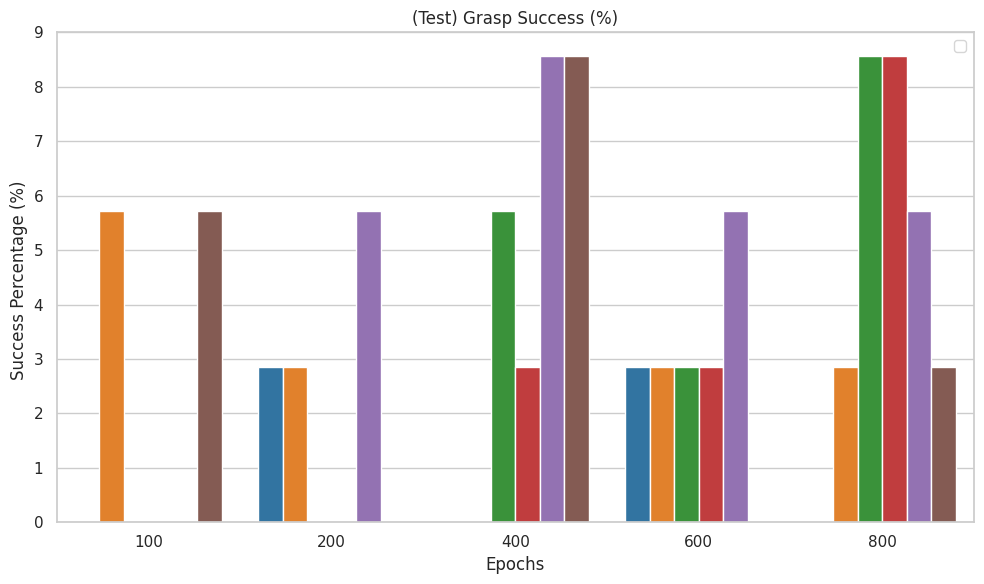

In [523]:
plt.figure(figsize=(10, 6))
sns.set_theme(style='whitegrid', palette='Set1')
sns.barplot(data=df_avg_dones, y='done_pct', x="condition", hue='config', palette='tab10', errorbar=None)
plt.title(f'Grasp Success (%)')
plt.legend(title="Fuse Config:")
plt.ylabel('Success Percentage (%) ')
plt.xlabel('Check Type')
savefig(f"evaluation/film/film-grasp-success-smaller.png")
plt.show()

plt.figure(figsize=(10, 6))
sns.set_theme(style='whitegrid', palette='Set1')
sns.barplot(data=df_avg_dones[df_avg_dones["condition"].str.contains("Control")], y='done_pct', x="epochs", hue='config', palette='tab10', errorbar=None)
plt.title(f'(Conrol) Grasp Success (%)')
plt.legend("")
plt.ylabel('Success Percentage (%) ')
plt.xlabel('Epochs')
savefig(f"evaluation/film/film-grasp-control-success-epochs-smaller.png")
plt.show()

plt.figure(figsize=(10, 6))
sns.set_theme(style='whitegrid', palette='Set1')
sns.barplot(data=df_avg_dones[df_avg_dones["condition"].str.contains("Test")], y='done_pct', x="epochs", hue='config', palette='tab10', errorbar=None)
plt.title(f'(Test) Grasp Success (%)')
plt.legend("")
plt.ylabel('Success Percentage (%) ')
plt.xlabel('Epochs')
savefig(f"evaluation/film/film-grasp-test-success-epochs-smaller.png")
plt.show()

## Big run Final

#### normal then small, currently doing the opposite



In [ ]:
comp_all = pd.read_csv("ZZ-normal-then-small-final/ALLvs_random-ns.csv")
comp_avg = pd.read_csv("ZZ-normal-then-small-final/vs_random-ns.csv")

df_avg_long_final, df_avg_long_min = final_and_min_melter(comp_avg)
df_avg_dones = done_count_melter(comp_avg)


#### smaller then normal

In [ ]:
configs = [
  FuseConfig.WDLR,
  FuseConfig.WLR_D,
  FuseConfig.DEPTH_FEATS_GATED,
  FuseConfig.DEPTH_FEATS_ATTN,
  FuseConfig.WD_LR,
  FuseConfig.WD_LR_ATTN,
  FuseConfig.Wfilm_D,
  # FuseConfig.W_Dfilm,
  FuseConfig.Wfilm_Dfilm,
  FuseConfig.Wfilm_D_LATE,
  FuseConfig.W_Dfilm_LATE,
  FuseConfig.Wfilm_Dfilm_LATE,
  FuseConfig.W_D_L_R,
  FuseConfig.W_D_L_R_FILM,
  # FuseConfig.W_D_L_R_ATTN, ##bad
]
# combine_multi_file_seed(
#   configs,
#   "ZZ-small-then-normal",
#   "vs_random-sn",
#   "{file}-cfg:{fuse_config}-seed{seed}"
# )

comp_all = pd.read_csv("ZZ-small-then-normal/ALLvs_random-sn.csv")
comp_avg = pd.read_csv("ZZ-small-then-normal/vs_random-sn.csv")

df_avg_long_final, df_avg_long_min = final_and_min_melter(comp_avg)
df_avg_dones = done_count_melter(comp_avg)

df_all_long_final, df_all_long_min = all_final_and_min_melter(comp_all)
df_all_dones = all_done_count_melter(comp_all)



In [ ]:
# Plot
g = sns.catplot(
    data=df_all_long_final[df_all_long_final["condition"].str.contains("control")],
    x='demo_idx',
    y='distance',
    hue='cam_type',
    row="config", 
    col='seed',
    # col_wrap=3,
    kind="box",
    errorbar=None,
    # markers=["."] * 10,
    palette="tab10",
    height=4,
    aspect=1,
)

# g.set_titles("Epochs: {row_name}, \n Fuse config: {col_name}")
g.set_titles("Fuse config: {col_name}")
g.set_axis_labels("Check Type", "Avg. Final Distance")
g.figure.suptitle("Average Final Distance per Check Type Other Training Params", y=1.02)#
# savefig(f"cam-comb/reach-obs/Z-ro_random-success.png", g = g)
plt.show()


In [ ]:
# Plot
g = sns.catplot(
    data=df_avg_long_min,
    x='condition',
    y='distance',
    hue='seed',
    col="config", 
    # row='epochs',
    col_wrap=3,
    kind="box",
    errorbar=None,
    # markers=["."] * 10,
    palette="tab10",
    height=4,
    aspect=1,
)

# g.set_titles("Epochs: {row_name}, \n Fuse config: {col_name}")
g.set_titles("Fuse config: {col_name}")
g.set_axis_labels("Check Type", "Avg. Minimum Distance")
g.figure.suptitle("Average Final Distance per Check Type Other Training Params", y=1.02)#
# savefig(f"cam-comb/reach-obs/Z-ro_random-success.png", g = g)
plt.show()


In [ ]:
# Plot
g = sns.catplot(
    data=df_all_long_final[df_all_long_final["condition"].str.contains("control")],
    x='demo_idx',
    y='distance',
    hue='cam_type',
    row="config", 
    col='seed',
    # col_wrap=3,
    kind="box",
    errorbar=None,
    # markers=["."] * 10,
    palette="tab10",
    height=4,
    aspect=1,
)

# g.set_titles("Epochs: {row_name}, \n Fuse config: {col_name}")
g.set_titles("Fuse config: {col_name}")
g.set_axis_labels("Check Type", "Avg. Final Distance")
g.figure.suptitle("Average Final Distance per Check Type Other Training Params", y=1.02)#
# savefig(f"cam-comb/reach-obs/Z-ro_random-success.png", g = g)
plt.show()


## baseline WLDR plots

#### normal then smaller test

In [491]:
comp_all = pd.read_csv("ZZ-normal-then-small-final/ALLvs_random-ns.csv")
comp_avg = pd.read_csv("ZZ-normal-then-small-final/vs_random-ns.csv")


df_base_all = comp_all[comp_all["config"] == f"{FuseConfig.WDLR}"]
df_base_avg = comp_avg[comp_avg["config"] == f"{FuseConfig.WDLR}"]

base_avg_long_final, base_avg_long_min = final_and_min_melter(df_base_avg)
base_avg_dones = done_count_melter(df_base_avg)
base_avg_dones["done_pct"] = base_avg_dones["done_count"].apply(lambda dc: dc * 10)

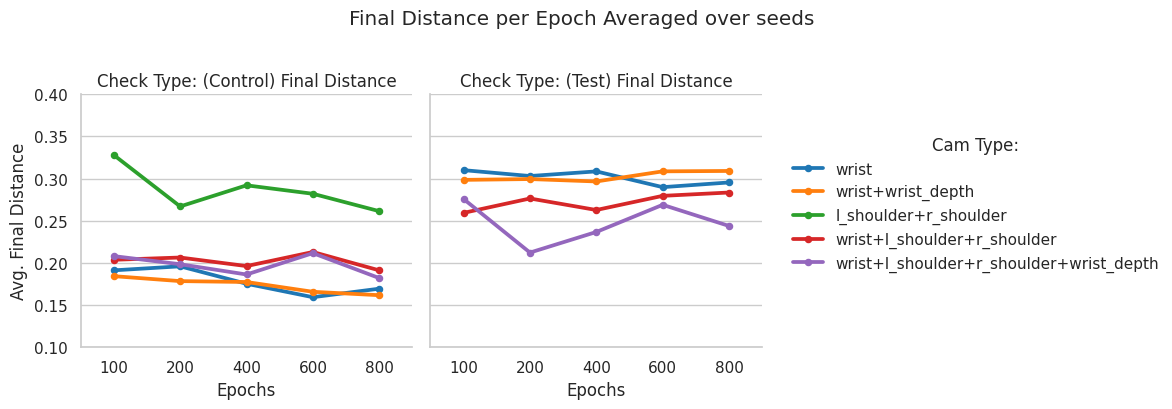

In [461]:
sns.set_theme(style='whitegrid', palette='Set1')
g = sns.catplot(
    data=base_avg_long_final,
    x='epochs',
    y='distance',
    hue='cam_type',
    col='condition',
    # row='seed',
    col_wrap=2,
    kind="point",
    errorbar=None,
    markers=["."] * 10,
    palette="tab10",
    height=4,
    aspect=1,
    # legend = None
)

g.set_titles("Check Type: {col_name}")
g.set_axis_labels("Epochs", "Avg. Final Distance")
g.figure.suptitle("Final Distance per Epoch Averaged over seeds", y=1.02)#
g.set(ylim=(0.1, 0.4))
g._legend.set_title("Cam Type:")
savefig(f"evaluation/baseline/base-grasp-final.png", g = g)
plt.show(g)


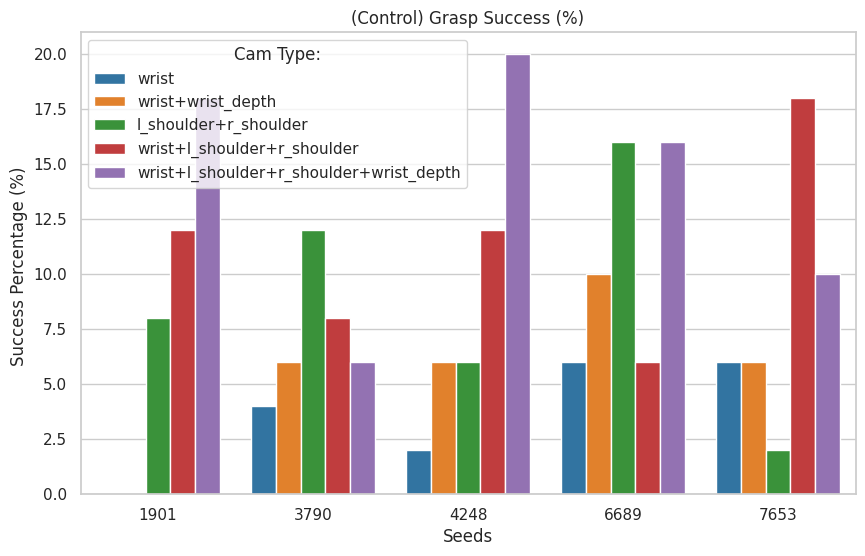

In [148]:
sns.set_theme(style='whitegrid', palette='Set1')
plt.figure(figsize=(10, 6))
sns.set_theme(style='whitegrid', palette='Set1')
sns.barplot(data=base_avg_dones[base_avg_dones["condition"].str.contains("Control")], y='done_pct', x="seed", hue='cam_type', palette='tab10', errorbar=None)
plt.title(f'(Control) Grasp Success (%)')
plt.ylabel('Success Percentage (%) ')
plt.legend(title="Cam Type:")
plt.xlabel('Seeds')
# savefig(f"evaluation/baseline/base-grasp-control-success-cams-seeds.png")
plt.show()


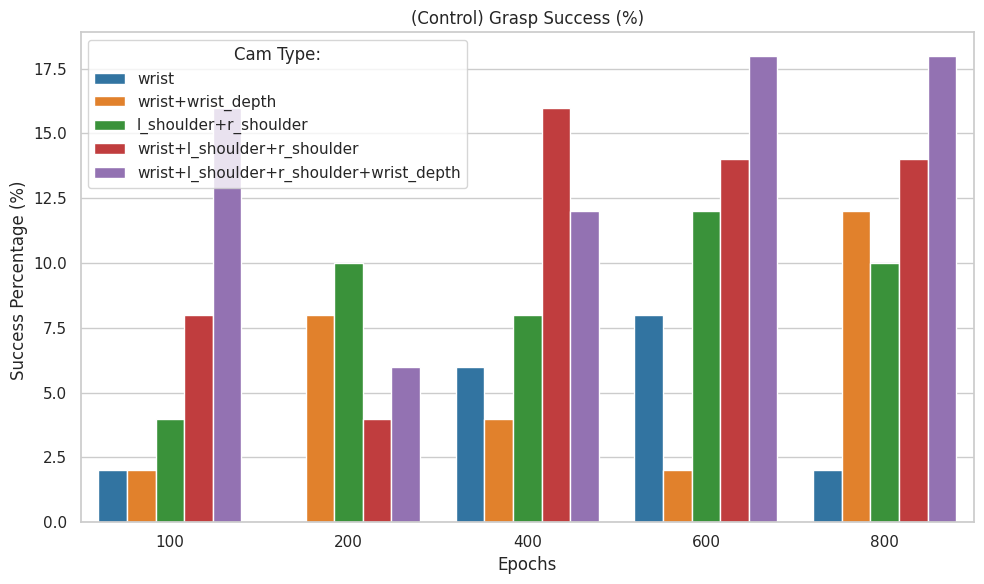

In [149]:
plt.figure(figsize=(10, 6))
sns.set_theme(style='whitegrid', palette='Set1')
sns.barplot(data=base_avg_dones[base_avg_dones["condition"].str.contains("Control")], y='done_pct', x="epochs", hue='cam_type', palette='tab10', errorbar=None)
plt.title(f'(Control) Grasp Success (%)')
plt.ylabel('Success Percentage (%) ')
plt.legend(title="Cam Type:")
plt.xlabel('Epochs')
savefig(f"evaluation/baseline/base-grasp-control-success-cams-epochs.png")
plt.show()

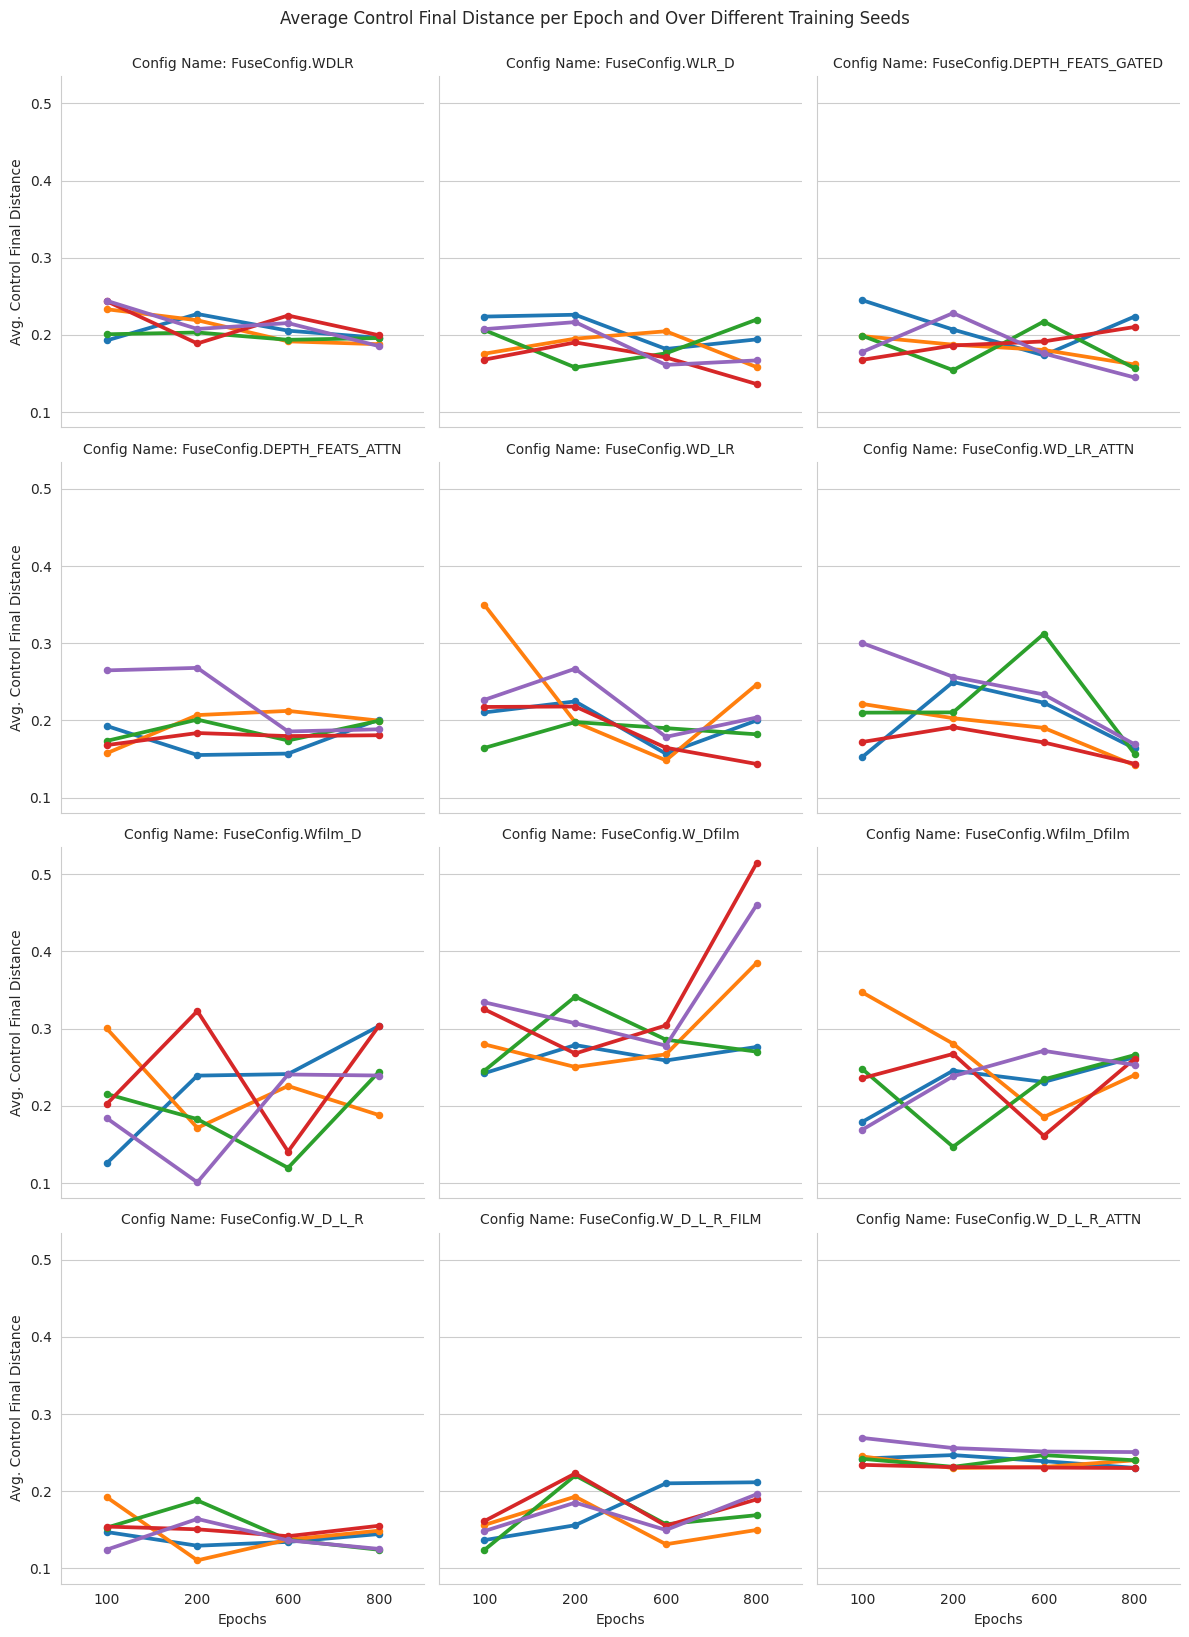

In [ ]:
# Plot
g = sns.catplot(
    data=comp_avg,
    x='epochs',
    y='avg_control_final_distance',
    hue='seed',
    col='config',
    col_wrap=3,
    kind="point",
    errorbar=None,
    markers=["."] * 10,
    palette="tab10",
    height=4,
    aspect=1,
    legend = None ## its just seed
)

g.set_titles("Config Name: {col_name}")
g.set_axis_labels("Epochs", "Avg. Control Final Distance")
g.figure.suptitle("Average Control Final Distance per Epoch and Over Different Training Seeds", y=1.02)#
# savefig(f"cam-comb/reach-obs/Z-ro_random-success.png", g = g)
plt.show()


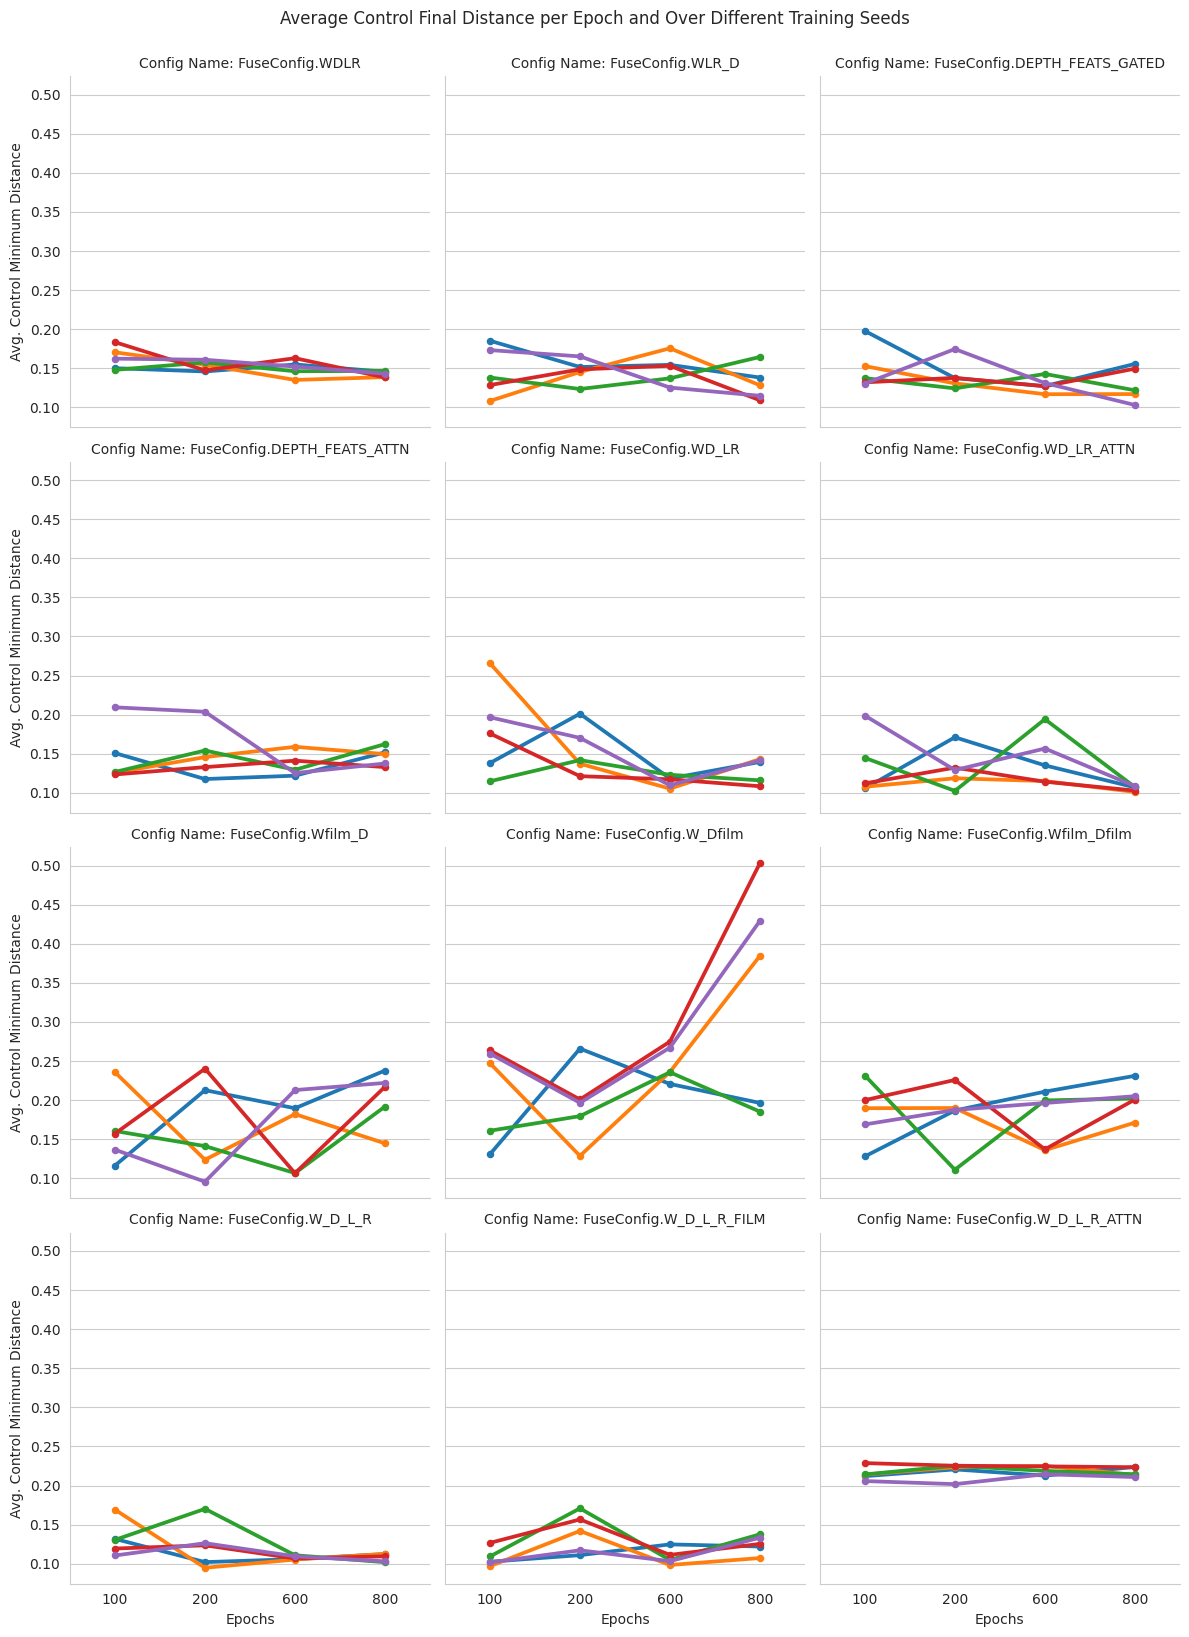

In [ ]:
# Plot
g = sns.catplot(
    data=comp_avg,
    x='epochs',
    y='avg_control_min_distance',
    hue='seed',
    col='config',
    col_wrap=3,
    kind="point",
    errorbar=None,
    markers=["."] * 10,
    palette="tab10",
    height=4,
    aspect=1,
    legend = None ## its just seed
)

g.set_titles("Config Name: {col_name}")
g.set_axis_labels("Epochs", "Avg. Control Minimum Distance")
g.figure.suptitle("Average Control Final Distance per Epoch and Over Different Training Seeds", y=1.02)#
# savefig(f"cam-comb/reach-obs/Z-ro_random-success.png", g = g)
plt.show()


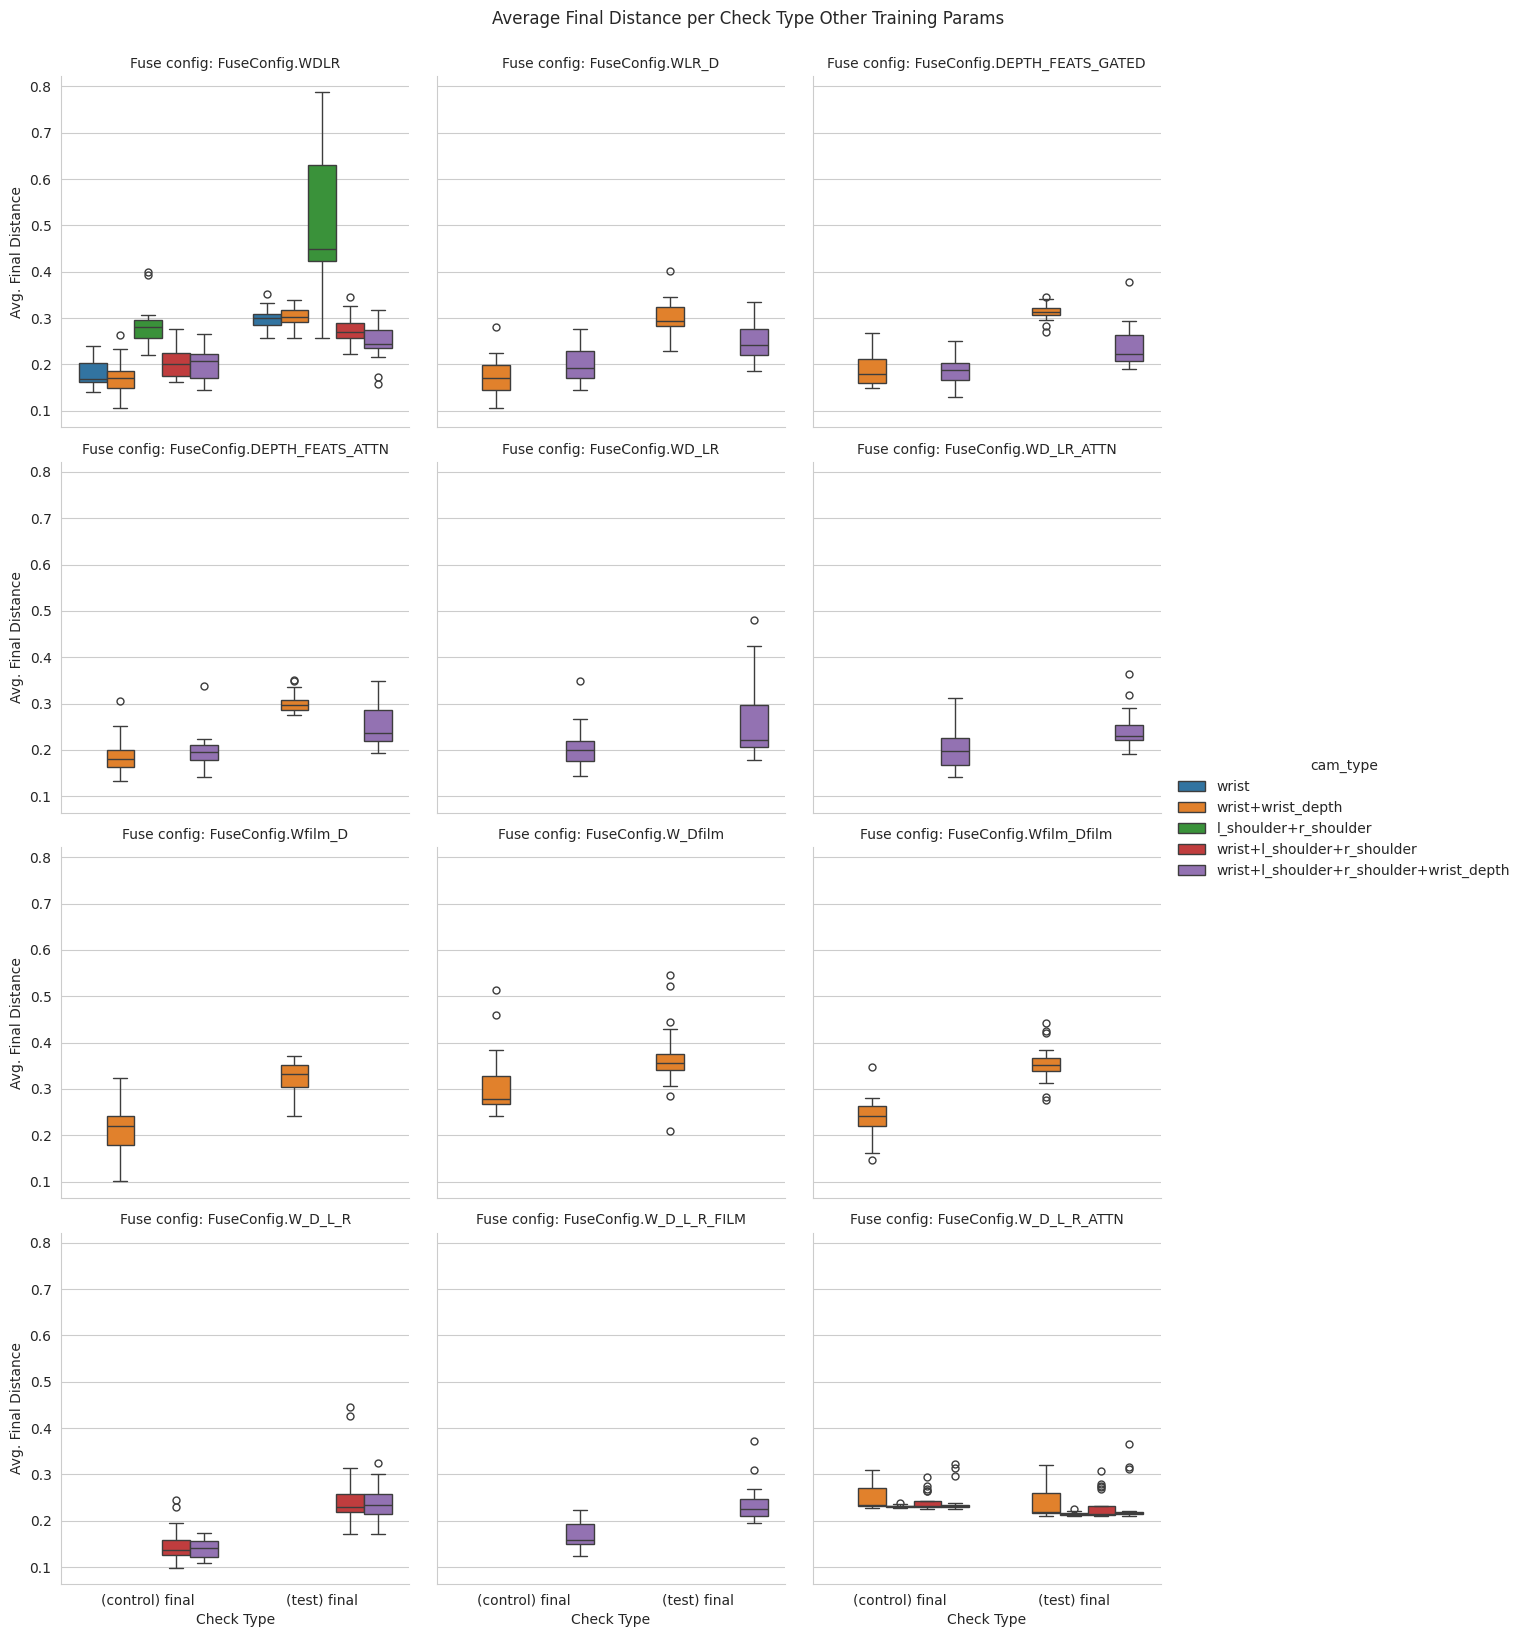

In [ ]:
# Plot
g = sns.catplot(
    data=df_avg_long_final,
    x='condition',
    y='distance',
    hue='cam_type',
    col="config", 
    # row='epochs',
    col_wrap=3,
    kind="box",
    errorbar=None,
    # markers=["."] * 10,
    palette="tab10",
    height=4,
    aspect=1,
)

# g.set_titles("Epochs: {row_name}, \n Fuse config: {col_name}")
g.set_titles("Fuse config: {col_name}")
g.set_axis_labels("Check Type", "Avg. Final Distance")
g.figure.suptitle("Average Final Distance per Check Type Other Training Params", y=1.02)#
# savefig(f"cam-comb/reach-obs/Z-ro_random-success.png", g = g)
plt.show()


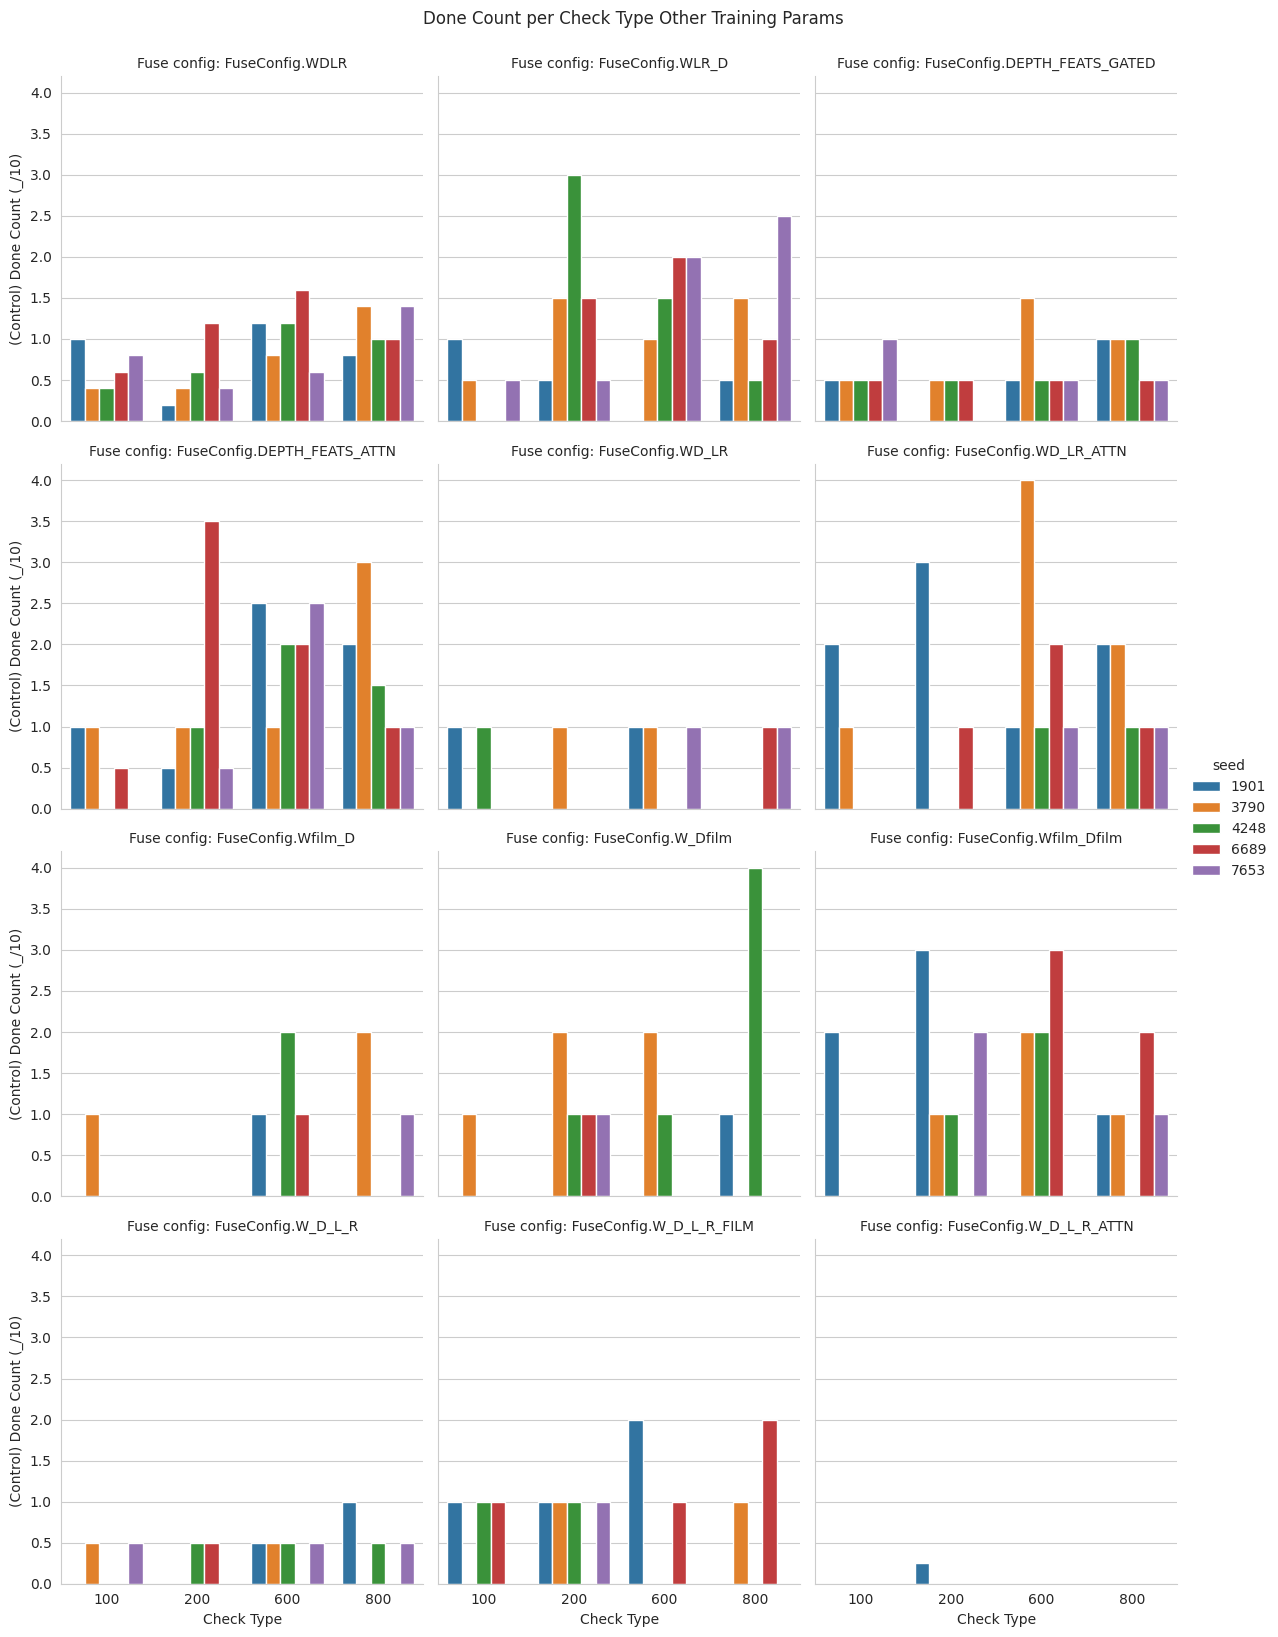

In [ ]:
##NOTE: presnet this in table form i think

df_avg_dones = done_count_melter(comp_avg)
# Plot
g = sns.catplot(
    data=df_avg_dones[df_avg_dones["condition"] == "control"],
    x='epochs',
    y='done_count',
    hue='seed',
    col="config", 
    # row='epochs',
    col_wrap=3,
    kind="bar",
    errorbar=None,
    # markers=["."] * 10,
    palette="tab10",
    height=4,
    aspect=1,
)

# g.set_titles("Epochs: {row_name}, \n Fuse config: {col_name}")
g.set_titles("Fuse config: {col_name}")
g.set_axis_labels("Check Type", "(Control) Done Count (_/10)")
g.figure.suptitle("Done Count per Check Type Other Training Params", y=1.02)#
# savefig(f"cam-comb/reach-obs/Z-ro_random-success.png", g = g)
plt.show()


#### smaller baseline


In [500]:
comp_all = pd.read_csv("ZZ-small-then-normal/ALLvs_random-sn.csv")

df_base_all = comp_all[comp_all["config"] == f"{FuseConfig.WDLR}"]

## TODO: need to remove index 0, 5, 6 from the all because we dont like them
df_base_all = df_base_all[~df_base_all["demo_idx"].isin([0., 5., 6.])]
df_base_avg = df_base_all.groupby([
  'epochs', 'cam_type', 'config', 'seed'
])[
  ["is_control_done",
  "is_test_done", 
  "control_final_distance",
  "test_final_distance",
  "control_min_distance",
  "test_min_distance",]
  ].mean().reset_index()
cams = df_base_avg["cam_type"].unique()
base_avg_long_final, base_avg_long_min = final_and_min_melter2(df_base_avg)
base_avg_dones = done_count_melter2(df_base_avg)
base_avg_dones["done_pct"] = base_avg_dones["done_count"].apply(lambda dc: float(dc) * 100) ##removed bad 3

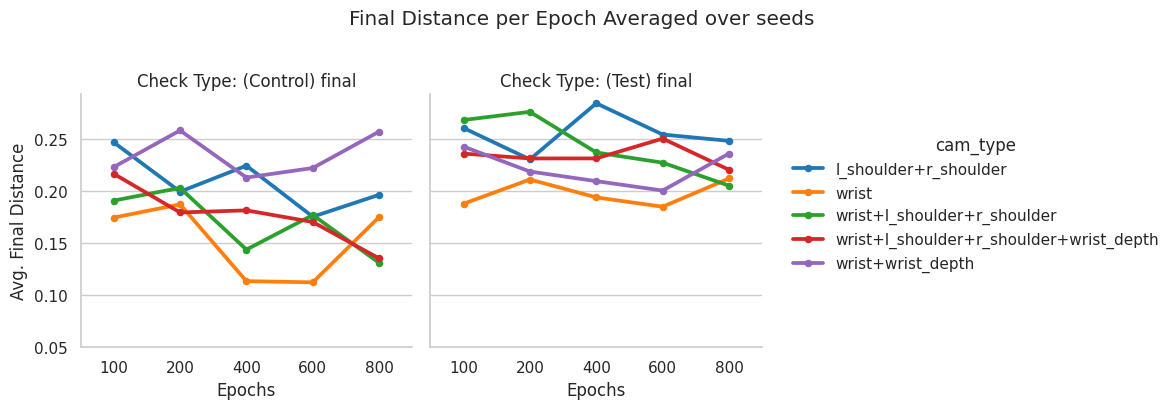

In [252]:
sns.set_theme(style='whitegrid', palette='Set1')
g = sns.catplot(
    data=base_avg_long_final,
    x='epochs',
    y='distance',
    hue='cam_type',
    hue_order=cams,
    col='condition',
    # row='seed',
    col_wrap=2,
    kind="point",
    errorbar=None,
    markers=["."] * 10,
    palette="tab10",
    height=4,
    aspect=1,
    # legend = None
)

g.set_titles("Check Type: {col_name}")
g.set_axis_labels("Epochs", "Avg. Final Distance")
g.figure.suptitle("Final Distance per Epoch Averaged over seeds", y=1.02)#
g.set(ylim=(0.05))
savefig(f"evaluation/baseline/base-grasp-final-smaller.png", g = g)
plt.show()


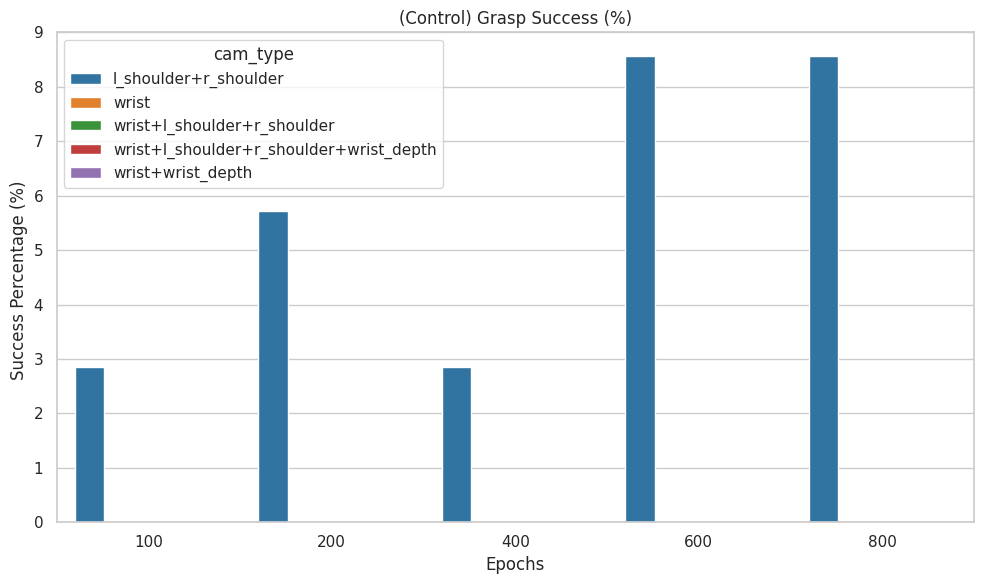

In [253]:
plt.figure(figsize=(10, 6))
sns.set_theme(style='whitegrid', palette='Set1')
sns.barplot(data=base_avg_dones[base_avg_dones["condition"].str.contains("Control")], y='done_pct', x="epochs", hue='cam_type', hue_order=cams, palette='tab10', errorbar=None)
plt.title(f'(Control) Grasp Success (%)')
plt.ylabel('Success Percentage (%) ')
# plt.legend("")
plt.xlabel('Epochs')
savefig(f"evaluation/baseline/base-smaller-grasp-control-success-cams-epochs.png")
plt.show()

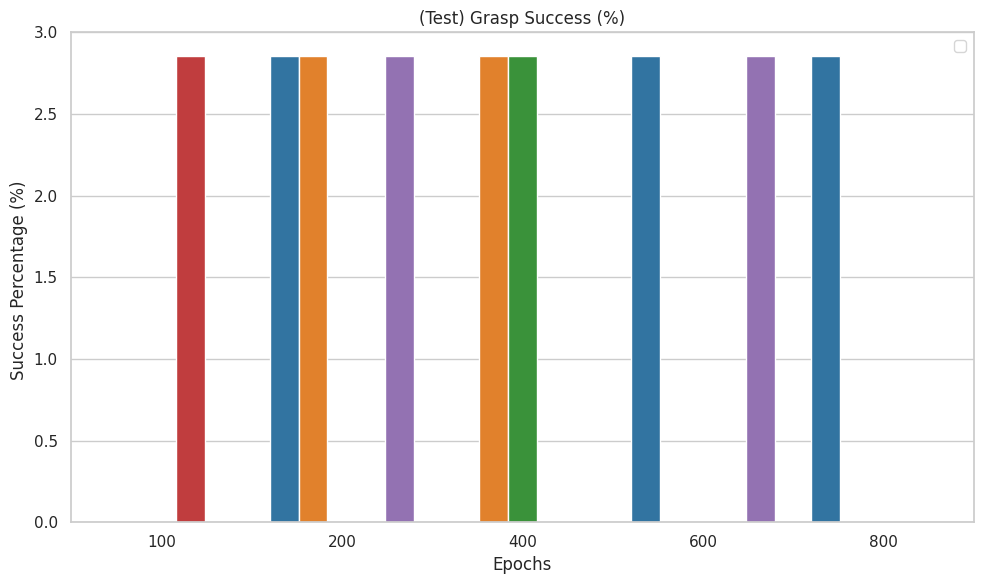

In [143]:
plt.figure(figsize=(10, 6))
sns.set_theme(style='whitegrid', palette='Set1')
sns.barplot(data=base_avg_dones[base_avg_dones["condition"].str.contains("Test")], y='done_pct', x="epochs", hue='cam_type', palette='tab10', errorbar=None)
plt.title(f'(Test) Grasp Success (%)')
plt.ylabel('Success Percentage (%) ')
plt.legend(title="Cam Type:")
plt.xlabel('Epochs')
plt.legend("")
savefig(f"evaluation/baseline/base-smaller-grasp-test-success-cams-epochs.png")
plt.show()

## SepDep methods

### doing normal
if it looks nice I wil include the smaller grasp, otherwise appendix

In [ ]:

comp_all = pd.read_csv("ZZ-normal-then-small-final/ALLvs_random-ns.csv")
comp_avg = pd.read_csv("ZZ-normal-then-small-final/vs_random-ns.csv")

configs = [

  FuseConfig.WDLR,
  FuseConfig.WLR_D,
  FuseConfig.DEPTH_FEATS_GATED,
  FuseConfig.DEPTH_FEATS_ATTN,
  FuseConfig.WD_LR,
  FuseConfig.WD_LR_ATTN,
]

cams = [
  "wrist+wrist_depth", 
  "wrist+l_shoulder+r_shoulder+wrist_depth"
]

comp_all = comp_all[comp_all["config"].isin(map(str, configs)) & comp_all["cam_type"].isin(cams)]
comp_avg = comp_avg[comp_avg["config"].isin(map(str, configs)) & comp_avg["cam_type"].isin(cams)]



df_avg_long_final, df_avg_long_min = final_and_min_melter(comp_avg)
df_avg_dones = done_count_melter(comp_avg)
df_avg_dones["done_pct"] = df_avg_dones["done_count"].apply(lambda dc: dc * 10)


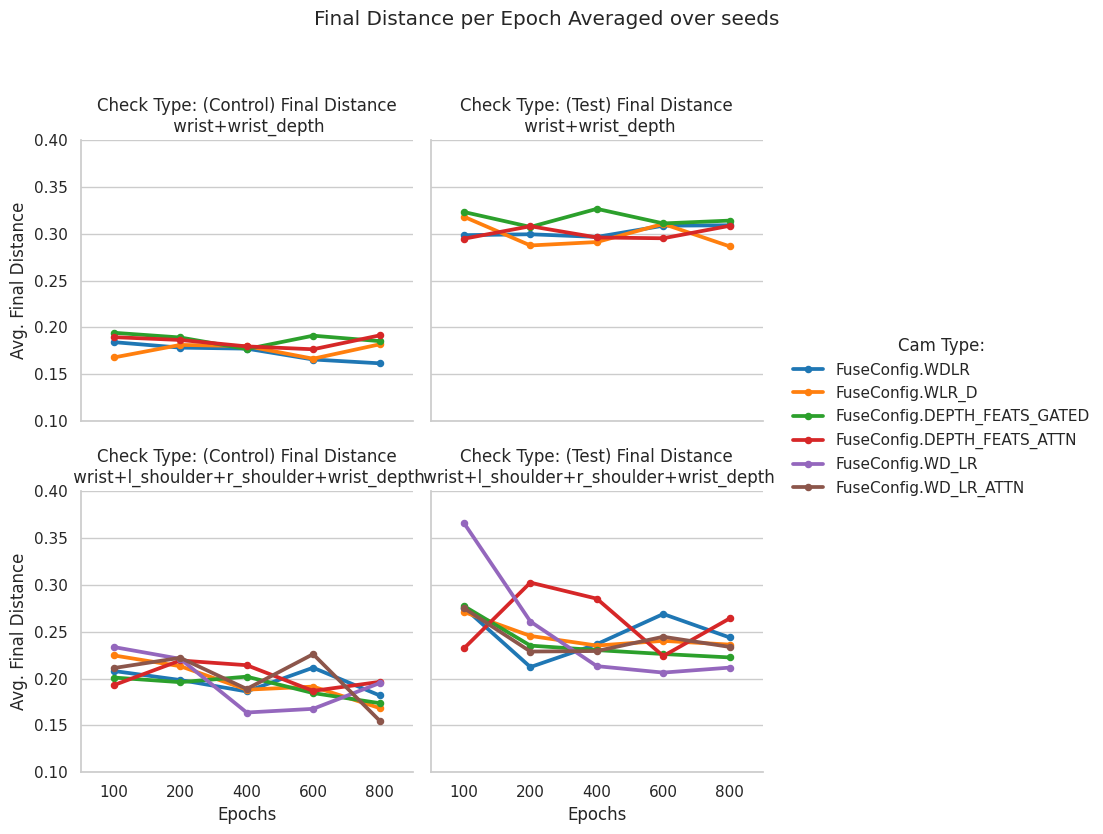

In [ ]:
sns.set_theme(style='whitegrid', palette='Set1')
g = sns.catplot(
    data=df_avg_long_final,
    x='epochs',
    y='distance',
    hue='config',
    col='condition',
    row='cam_type',
    # col_wrap=2,
    kind="point",
    errorbar=None,
    markers=["."] * 10,
    palette="tab10",
    height=4,
    aspect=1,
    # legend = None
)
g.figure.subplots_adjust(hspace=0.2, wspace=0.2)
g.set_titles("Check Type: {col_name}\n {row_name}")
g.set_axis_labels("Epochs", "Avg. Final Distance")
g.figure.suptitle("Final Distance per Epoch Averaged over seeds", y=1.04)#
g.set(ylim=(0.1, 0.4))
g._legend.set_title("Cam Type:")
savefig(f"evaluation/sep-dep/Z-grasp-normal-final-cams.png", g = g)
plt.show(g)
##TODO: add the 400 epochs runing now 'ALLvs_random-ns-sepdeps-400eps.csv'

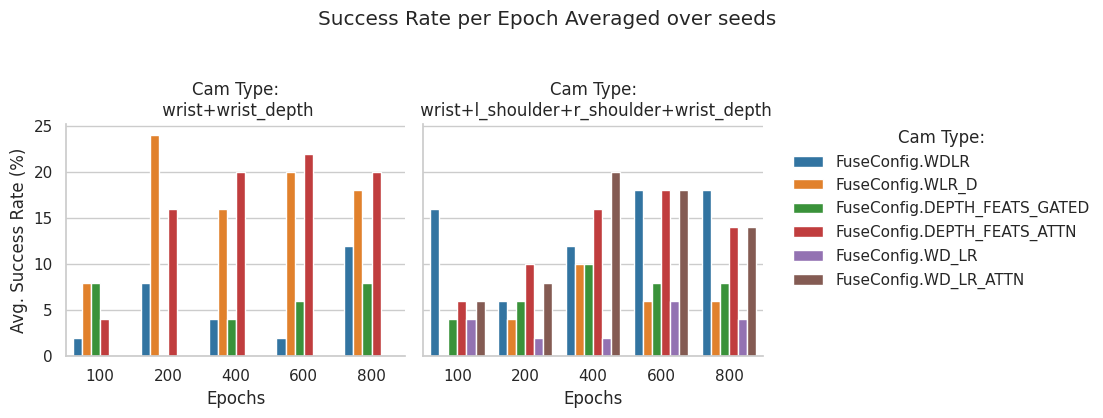

In [489]:
sns.set_theme(style='whitegrid', palette='Set1')
g = sns.catplot(
    data=df_avg_dones[df_avg_dones["condition"].str.contains("Control")],
    x='epochs',
    y='done_pct',
    hue='config',
    col='cam_type',
    # row='cam_type',
    col_wrap=2,
    kind="bar",
    errorbar=None,
    palette="tab10",
    height=4,
    aspect=1,
    # legend = None
)
g.figure.subplots_adjust(hspace=0.2, wspace=0.2)
g.set_titles("Cam Type:\n {col_name}")
g.set_axis_labels("Epochs", "Avg. Success Rate (%)")
g.figure.suptitle("Success Rate per Epoch Averaged over seeds", y=1.04)#
g._legend.set_title("Cam Type:")
savefig(f"evaluation/sep-dep/grasp-normal-success-cams.png", g = g)
plt.show(g)


### small then normal

In [ ]:
comp_all = pd.read_csv("ZZ-small-then-normal/ALLvs_random-sn.csv")

configs = [

  FuseConfig.WDLR,
  FuseConfig.WLR_D,
  FuseConfig.DEPTH_FEATS_GATED,
  FuseConfig.DEPTH_FEATS_ATTN,
  FuseConfig.WD_LR,
  FuseConfig.WD_LR_ATTN,
]

cams = [
  "wrist+wrist_depth", 
  "wrist+l_shoulder+r_shoulder+wrist_depth"
]

comp_all = comp_all[comp_all["config"].isin(map(str, configs)) & comp_all["cam_type"].isin(cams)]
comp_all = comp_all[~comp_all["demo_idx"].isin([0., 5., 6.])]
comp_avg = comp_all.groupby([
  "seed", "config", "cam_type", "epochs" 
])[
  ["is_control_done",
  "is_test_done", 
  "control_final_distance",
  "test_final_distance",
  "control_min_distance",
  "test_min_distance",]
  ].mean().reset_index()


df_avg_long_final, df_avg_long_min = final_and_min_melter2(comp_avg)
df_avg_dones = done_count_melter2(comp_avg)
df_avg_dones["done_pct"] = df_avg_dones["done_count"].apply(lambda dc: dc * 100)

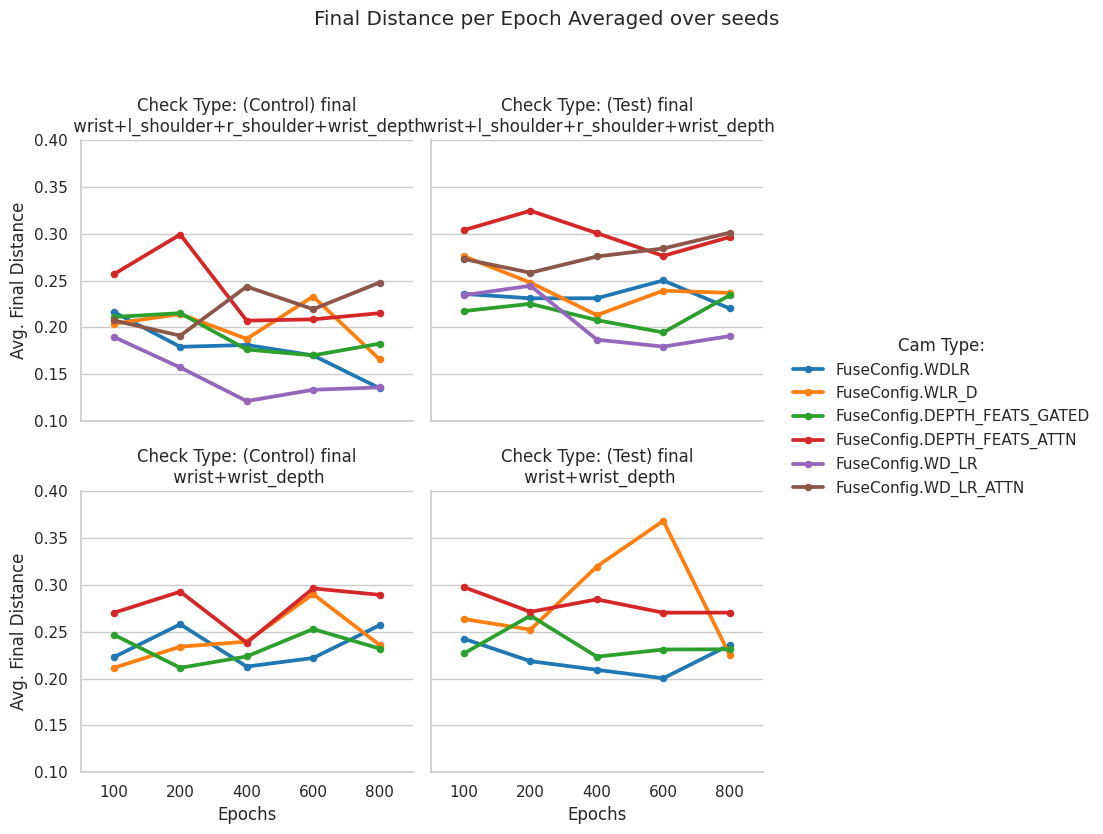

In [ ]:
sns.set_theme(style='whitegrid', palette='Set1')
g = sns.catplot(
    data=df_avg_long_final,
    x='epochs',
    y='distance',
    hue='config',
    col='condition',
    row='cam_type',
    hue_order=list(map(str, configs)),
    # col_wrap=2,
    kind="point",
    errorbar=None,
    markers=["."] * 10,
    palette="tab10",
    height=4,
    aspect=1,
    # legend = None
)
g.figure.subplots_adjust(hspace=0.2, wspace=0.2)
g.set_titles("Check Type: {col_name}\n {row_name}")
g.set_axis_labels("Epochs", "Avg. Final Distance")
g.figure.suptitle("Final Distance per Epoch Averaged over seeds", y=1.04)#
g.set(ylim=(0.1, 0.4))
g._legend.set_title("Cam Type:")
savefig(f"evaluation/sep-dep/Z-grasp-smaller-final-cams.png", g = g)
plt.show(g)
##TODO: add the 400 epochs runing now 'ALLvs_random-ns-sepdeps-400eps.csv'

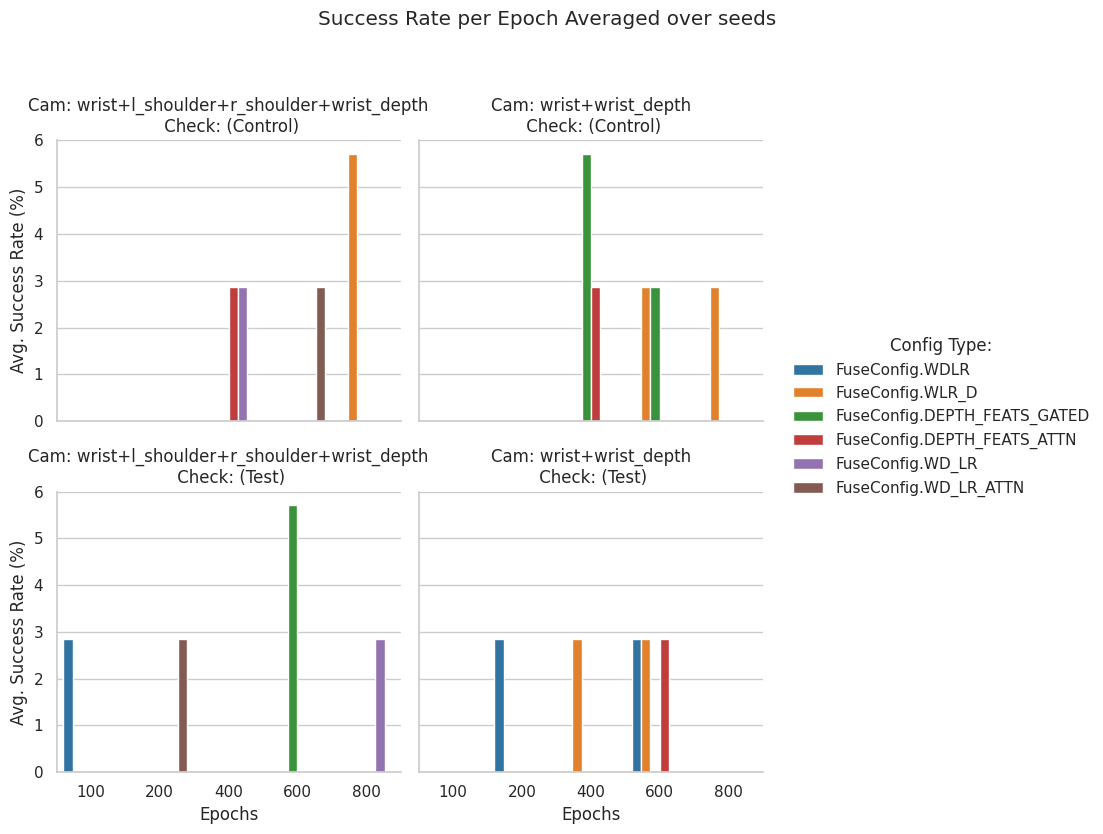

In [258]:

# df_avg_dones = df_avg_dones[df_avg_dones["config"] != f"{FuseConfig.WDLR}"]

g = sns.catplot(
    data=df_avg_dones,
    x='epochs',
    y='done_pct',
    hue='config',
    hue_order=list(map(str, configs)),
    row ="condition",
    col='cam_type',
    # col_wrap=2,
    kind="bar",
    errorbar=None,
    palette="tab10",
    height=4,
    aspect=1,
    # legend = None
)
g.figure.subplots_adjust(hspace=0.2, wspace=0.2)
g.set_titles("Cam: {col_name}\n Check: {row_name}")
g.set_axis_labels("Epochs", "Avg. Success Rate (%)")
g.figure.suptitle("Success Rate per Epoch Averaged over seeds", y=1.04)#
g._legend.set_title("Config Type:")
savefig(f"evaluation/sep-dep/Z-grasp-smaller-success-cams-config.png", g = g)
plt.show(g)


## Derivatives


In [ ]:
comp_all = pd.read_csv("ZZ-normal-then-small-final/ALLvs_random-ns.csv")
comp_avg = pd.read_csv("ZZ-normal-then-small-final/vs_random-ns.csv")

configs = [
  FuseConfig.WDLR,
  FuseConfig.W_D_L_R,
  FuseConfig.W_D_L_R_FILM,
  FuseConfig.W_D_L_R_ATTN,
]

# cams = [
#   "wrist+wrist_depth", 
#   "wrist+l_shoulder+r_shoulder+wrist_depth"
# ]

comp_all = comp_all[
  comp_all["config"].isin(map(str, configs)) 
  & comp_all["cam_type"].isin(cams)
  & (comp_all["epochs"] != 400)
]
comp_avg = comp_avg[
  comp_avg["config"].isin(map(str, configs)) 
  & comp_avg["cam_type"].isin(cams)
  & (comp_avg["epochs"] != 400)
]



df_avg_long_final, df_avg_long_min = final_and_min_melter(comp_avg)
df_avg_dones = done_count_melter(comp_avg)
df_avg_dones["done_pct"] = df_avg_dones["done_count"].apply(lambda dc: dc * 10)


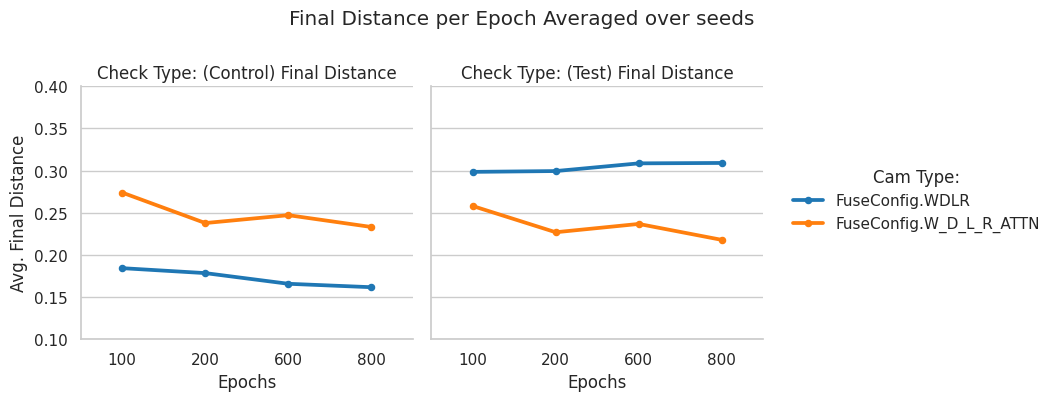

In [ ]:
sns.set_theme(style='whitegrid', palette='Set1')
g = sns.catplot(
    data=df_avg_long_final[df_avg_long_final["cam_type"] == "wrist+wrist_depth"],
    x='epochs',
    y='distance',
    hue='config',
    col='condition',
    row='cam_type',
    # col_wrap=2,
    kind="point",
    errorbar=None,
    markers=["."] * 10,
    palette="tab10",
    height=4,
    aspect=1,
    # legend = None
)
g.figure.subplots_adjust(hspace=0.2, wspace=0.2)
g.set_titles("Check Type: {col_name}")
g.set_axis_labels("Epochs", "Avg. Final Distance")
g.figure.suptitle("Final Distance per Epoch Averaged over seeds", y=1.00)#
g.set(ylim=(0.1, 0.4))
g._legend.set_title("Cam Type:")
savefig(f"evaluation/derivatives/grasp-normal-wd.png", g = g)
plt.show(g)

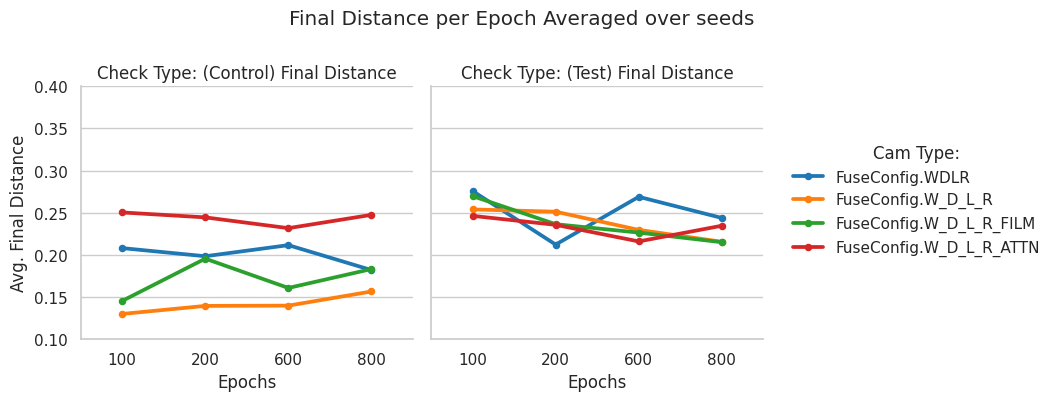

In [ ]:
sns.set_theme(style='whitegrid', palette='Set1')
g = sns.catplot(
    data=df_avg_long_final[df_avg_long_final["cam_type"] == "wrist+l_shoulder+r_shoulder+wrist_depth"],
    x='epochs',
    y='distance',
    hue='config',
    col='condition',
    row='cam_type',
    # col_wrap=2,
    kind="point",
    errorbar=None,
    markers=["."] * 10,
    palette="tab10",
    height=4,
    aspect=1,
    # legend = None
)
g.figure.subplots_adjust(hspace=0.2, wspace=0.2)
g.set_titles("Check Type: {col_name}")
g.set_axis_labels("Epochs", "Avg. Final Distance")
g.figure.suptitle("Final Distance per Epoch Averaged over seeds", y=1.0)#
g.set(ylim=(0.1, 0.4))
g._legend.set_title("Cam Type:")
savefig(f"evaluation/derivatives/grasp-normal-allcams.png", g = g)
plt.show(g)
##TODO: add the 400 epochs runing now 'ALLvs_random-ns-sepdeps-400eps.csv'

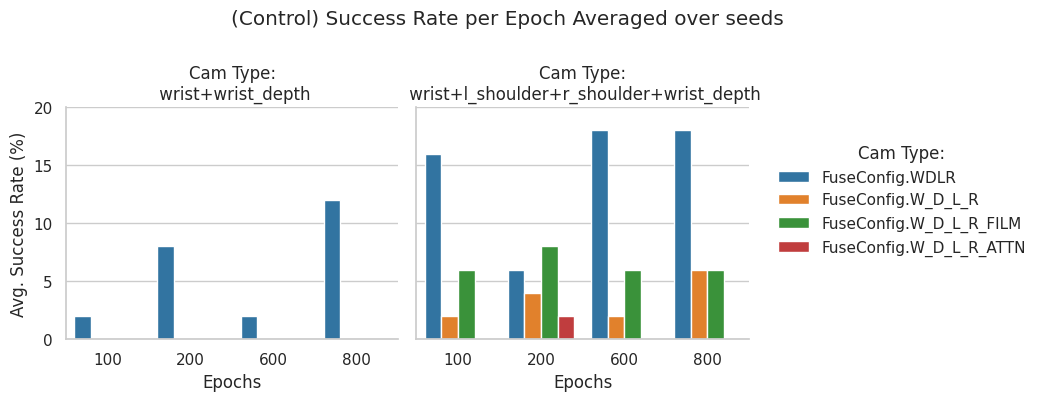

In [305]:
sns.set_theme(style='whitegrid', palette='Set1')
g = sns.catplot(
    data=df_avg_dones[df_avg_dones["condition"].str.contains("Control")],
    x='epochs',
    y='done_pct',
    hue='config',
    col='cam_type',
    # row='cam_type',
    col_wrap=2,
    kind="bar",
    errorbar=None,
    palette="tab10",
    height=4,
    aspect=1,
    # legend = None
)
g.figure.subplots_adjust(hspace=0.2, wspace=0.2)
g.set_titles("Cam Type:\n {col_name}")
g.set_axis_labels("Epochs", "Avg. Success Rate (%)")
g.figure.suptitle("(Control) Success Rate per Epoch Averaged over seeds", y=1.00)#
g._legend.set_title("Cam Type:")
g.set(ylim=(0, 20))
savefig(f"evaluation/derivatives/grasp-normal-control-success-cams.png", g = g)
plt.show(g)


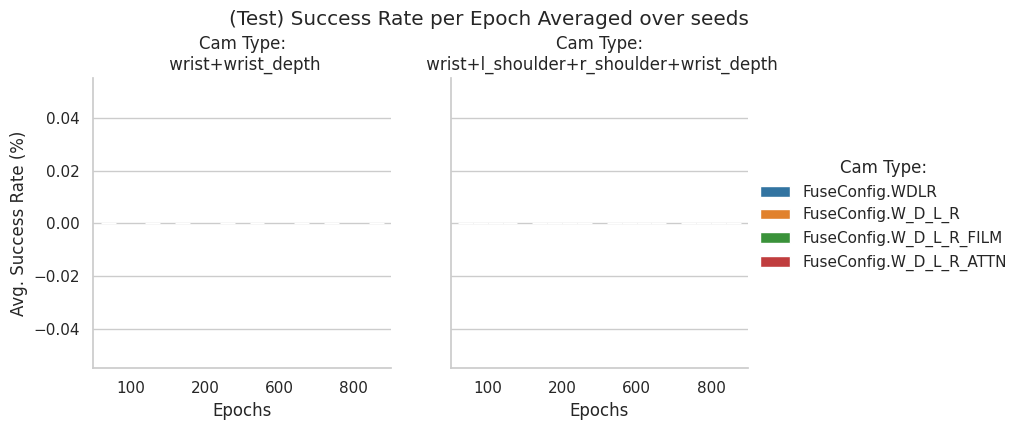

In [293]:
sns.set_theme(style='whitegrid', palette='Set1')
g = sns.catplot(
    data=df_avg_dones[df_avg_dones["condition"].str.contains("Test")],
    x='epochs',
    y='done_pct',
    hue='config',
    col='cam_type',
    # row='cam_type',
    col_wrap=2,
    kind="bar",
    errorbar=None,
    palette="tab10",
    height=4,
    aspect=1,
    # legend = None
)
g.figure.subplots_adjust(hspace=0.2, wspace=0.2)
g.set_titles("Cam Type:\n {col_name}")
g.set_axis_labels("Epochs", "Avg. Success Rate (%)")
g.figure.suptitle("(Test) Success Rate per Epoch Averaged over seeds", y=1.07)#
g._legend.set_title("Cam Type:")
# savefig(f"evaluation/sep-dep/grasp-normal-success-cams.png", g = g)
plt.show(g)


### smaller train then normal

In [ ]:
comp_all = pd.read_csv("ZZ-small-then-normal/ALLvs_random-sn.csv")

configs = [

  FuseConfig.WDLR,
  FuseConfig.W_D_L_R,
  FuseConfig.W_D_L_R_FILM,
  FuseConfig.W_D_L_R_ATTN,
]

cams = [
  "wrist+wrist_depth", 
  "wrist+l_shoulder+r_shoulder+wrist_depth"
]

comp_all = comp_all[comp_all["config"].isin(map(str, configs)) & comp_all["cam_type"].isin(cams)]
comp_all = comp_all[~comp_all["demo_idx"].isin([0., 5., 6.])]
comp_avg = comp_all.groupby([
  "seed", "config", "cam_type", "epochs" 
])[
  ["is_control_done",
  "is_test_done", 
  "control_final_distance",
  "test_final_distance",
  "control_min_distance",
  "test_min_distance",]
  ].mean().reset_index()


df_avg_long_final, df_avg_long_min = final_and_min_melter2(comp_avg)
df_avg_dones = done_count_melter2(comp_avg)
df_avg_dones["done_pct"] = df_avg_dones["done_count"].apply(lambda dc: dc * 100)

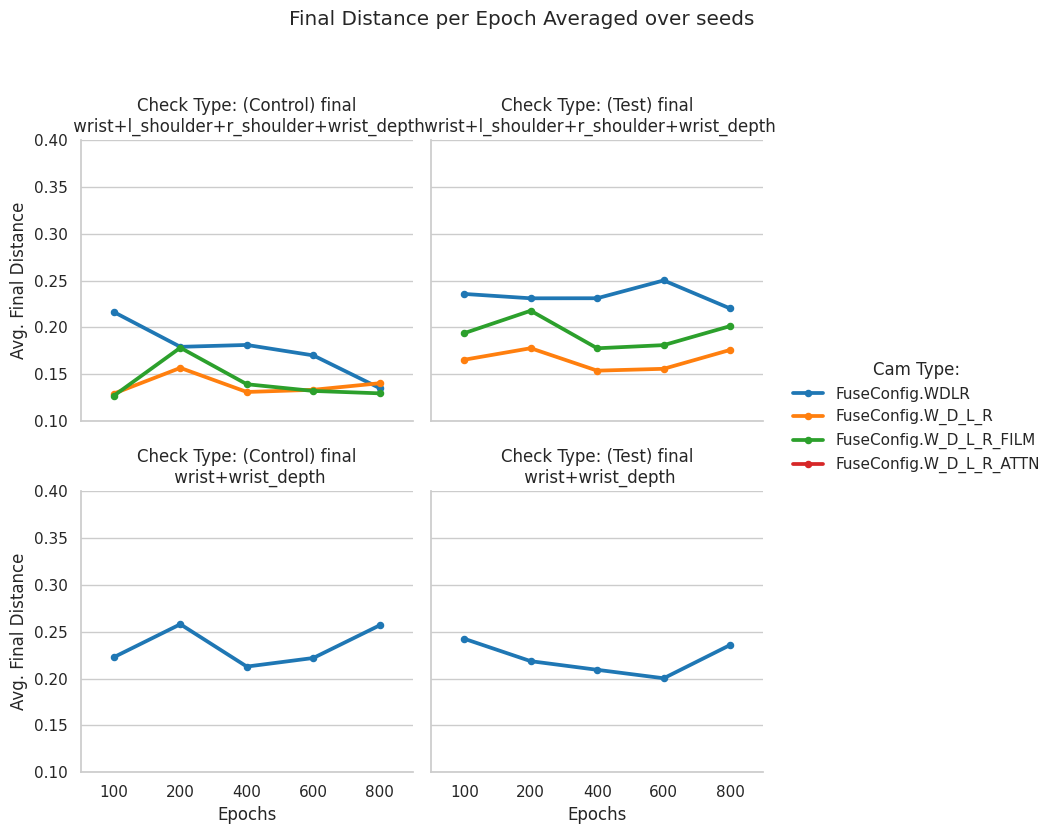

In [ ]:
sns.set_theme(style='whitegrid', palette='Set1')
g = sns.catplot(
    data=df_avg_long_final,
    x='epochs',
    y='distance',
    hue='config',
    col='condition',
    row='cam_type',
    hue_order=list(map(str, configs)),
    # col_wrap=2,
    kind="point",
    errorbar=None,
    markers=["."] * 10,
    palette="tab10",
    height=4,
    aspect=1,
    # legend = None
)
g.figure.subplots_adjust(hspace=0.2, wspace=0.2)
g.set_titles("Check Type: {col_name}\n {row_name}")
g.set_axis_labels("Epochs", "Avg. Final Distance")
g.figure.suptitle("Final Distance per Epoch Averaged over seeds", y=1.04)#
g.set(ylim=(0.1, 0.4))
g._legend.set_title("Cam Type:")
savefig(f"evaluation/derivatives/Z-grasp-smaller-final-cams.png", g = g)
plt.show(g)
##TODO: add the 400 epochs runing now 'ALLvs_random-ns-sepdeps-400eps.csv'

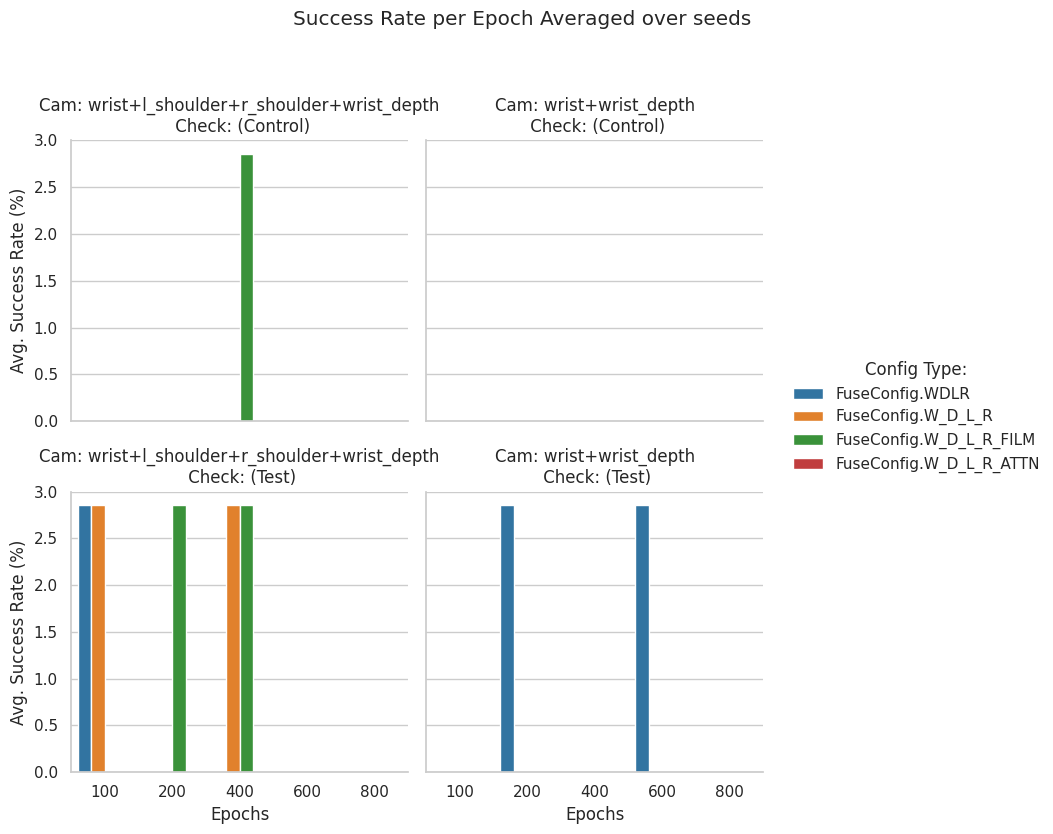

In [311]:

# df_avg_dones = df_avg_dones[df_avg_dones["config"] != f"{FuseConfig.WDLR}"]

g = sns.catplot(
    data=df_avg_dones,
    x='epochs',
    y='done_pct',
    hue='config',
    hue_order=list(map(str, configs)),
    row ="condition",
    col='cam_type',
    # col_wrap=2,
    kind="bar",
    errorbar=None,
    palette="tab10",
    height=4,
    aspect=1,
    # legend = None
)
g.figure.subplots_adjust(hspace=0.2, wspace=0.2)
g.set_titles("Cam: {col_name}\n Check: {row_name}")
g.set_axis_labels("Epochs", "Avg. Success Rate (%)")
g.figure.suptitle("Success Rate per Epoch Averaged over seeds", y=1.04)#
g._legend.set_title("Config Type:")
savefig(f"evaluation/derivatives/Z-grasp-smaller-success-cams-config.png", g = g)
plt.show(g)


# LSTM run
lstm data is mainly discussed in plots.

## normal then small
done only one seed, seed = 3790


In [18]:
rnn_avg = pd.read_csv("ZZ-lstm-run/vs_random-ns.csv")

avg_long_final, df_avg_long_min = final_and_min_melter(rnn_avg)
df_avg_dones = done_count_melter(rnn_avg)


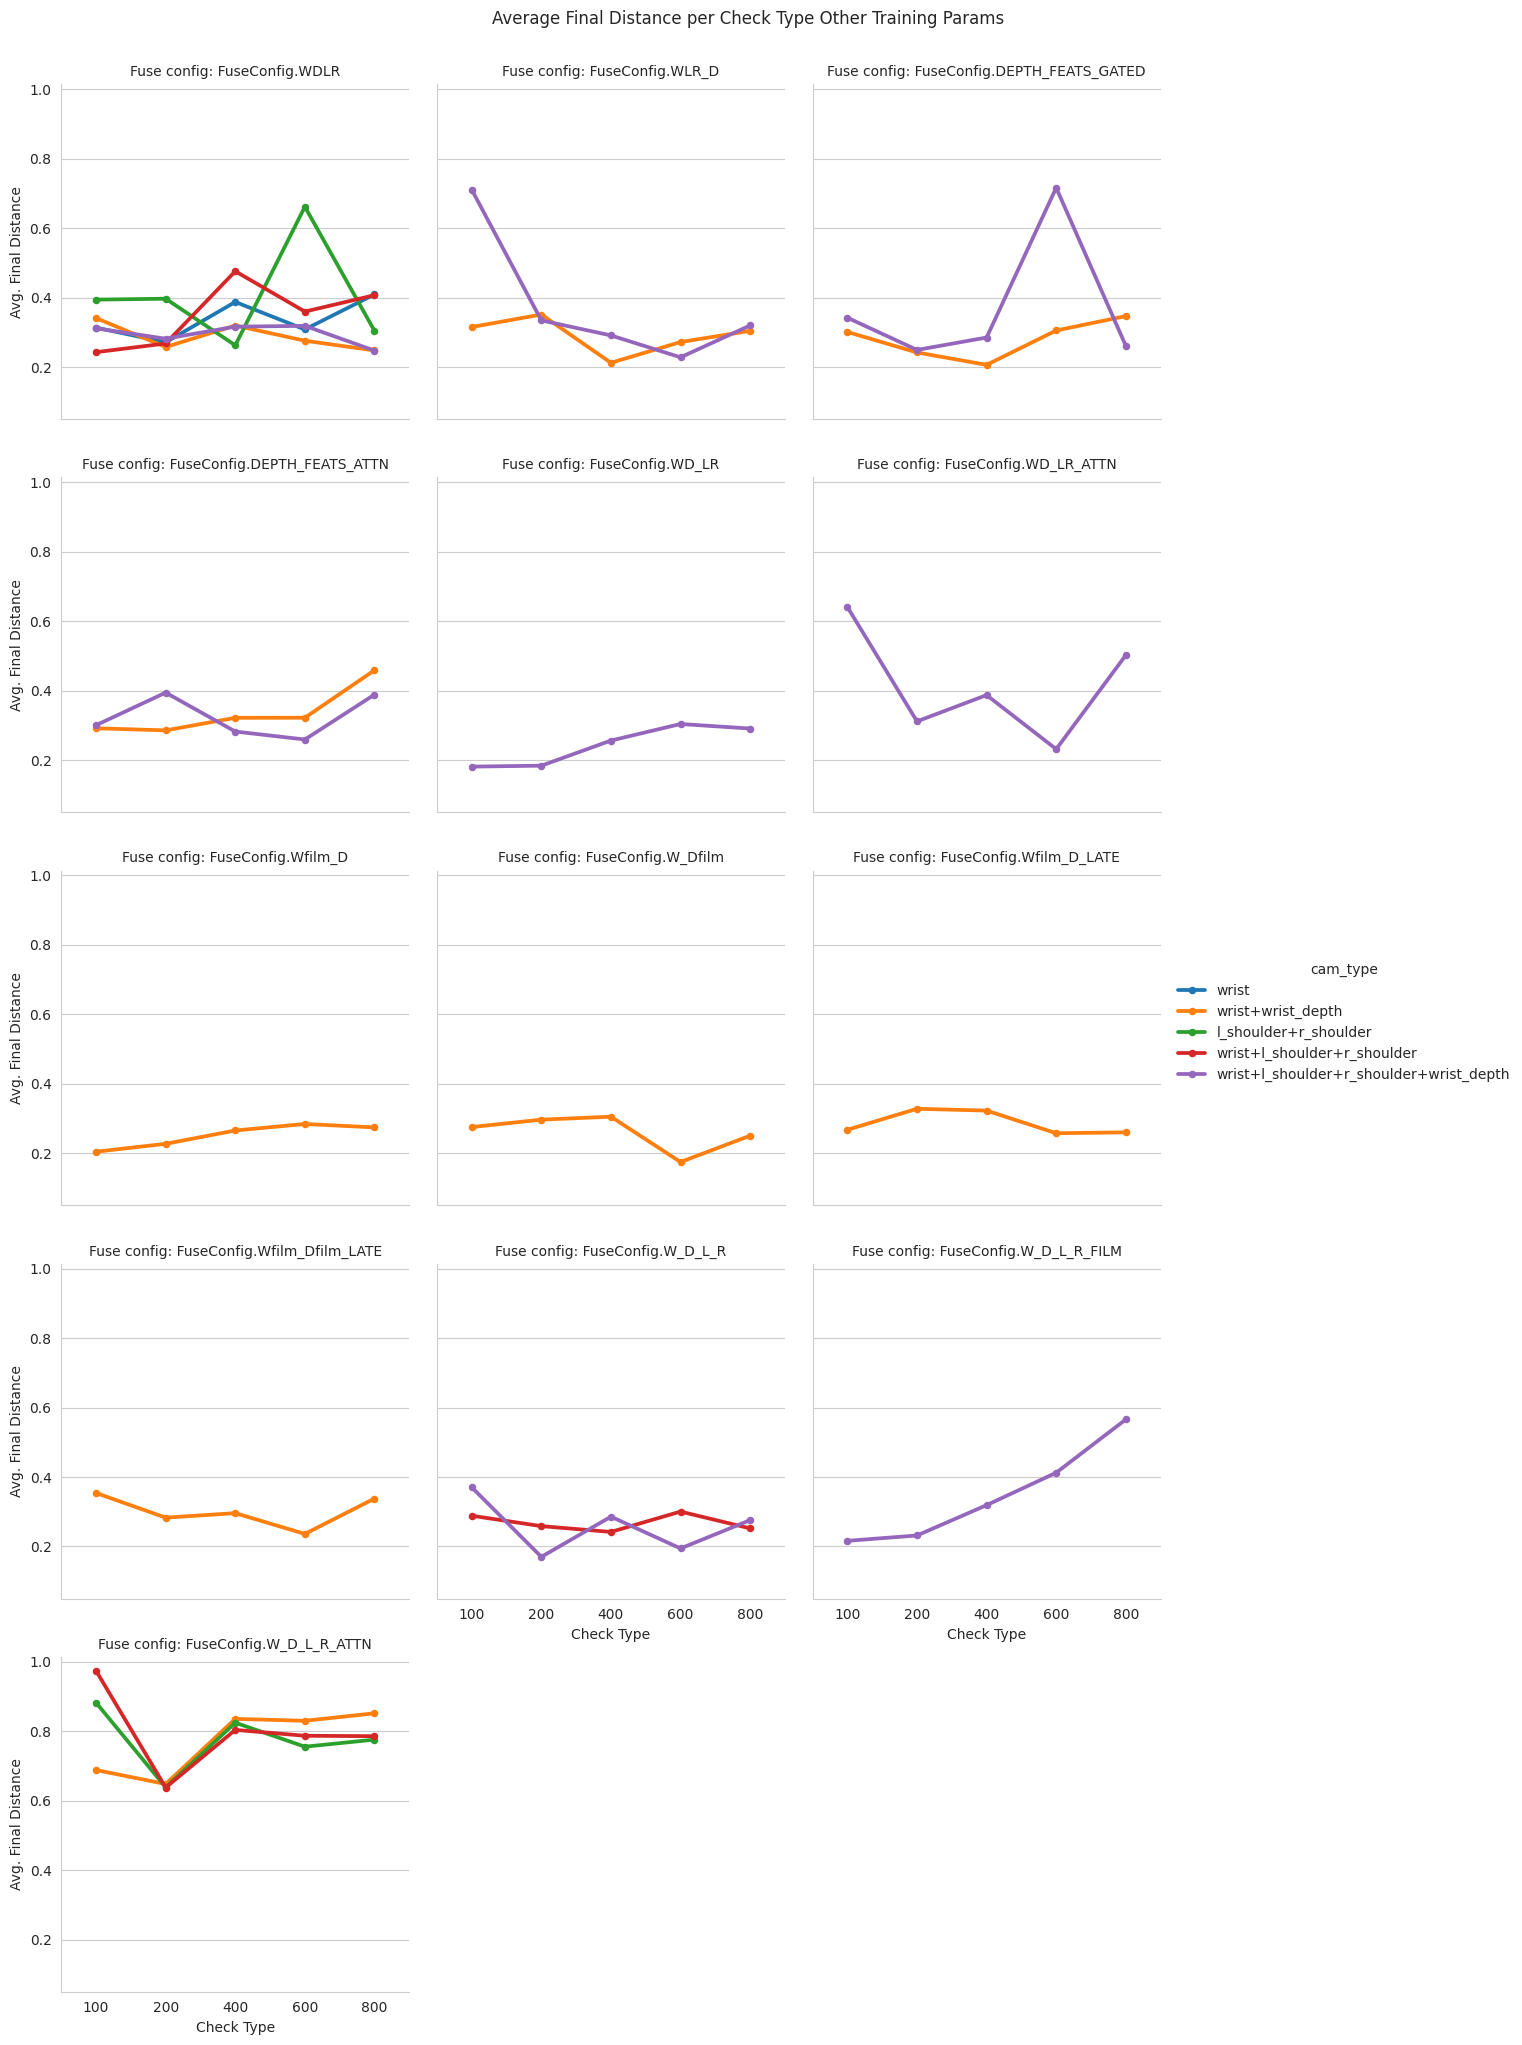

In [19]:
# Plot
g = sns.catplot(
    data=avg_long_final[avg_long_final["condition"].str.contains("Control")],
    x='epochs',
    y='distance',
    hue='cam_type',
    # row="config", 
    col='config',
    col_wrap=3,
    kind="point",
    errorbar=None,
    markers=["."] * 10,
    palette="tab10",
    height=4,
    aspect=1,
)

# g.set_titles("Epochs: {row_name}, \n Fuse config: {col_name}")
g.set_titles("Fuse config: {col_name}")
g.set_axis_labels("Check Type", "Avg. Final Distance")
g.set(ylim=(0.05))
g.figure.suptitle("Average Final Distance per Check Type Other Training Params", y=1.02)#
# savefig(f"cam-comb/reach-obs/Z-ro_random-success.png", g = g)
plt.show()


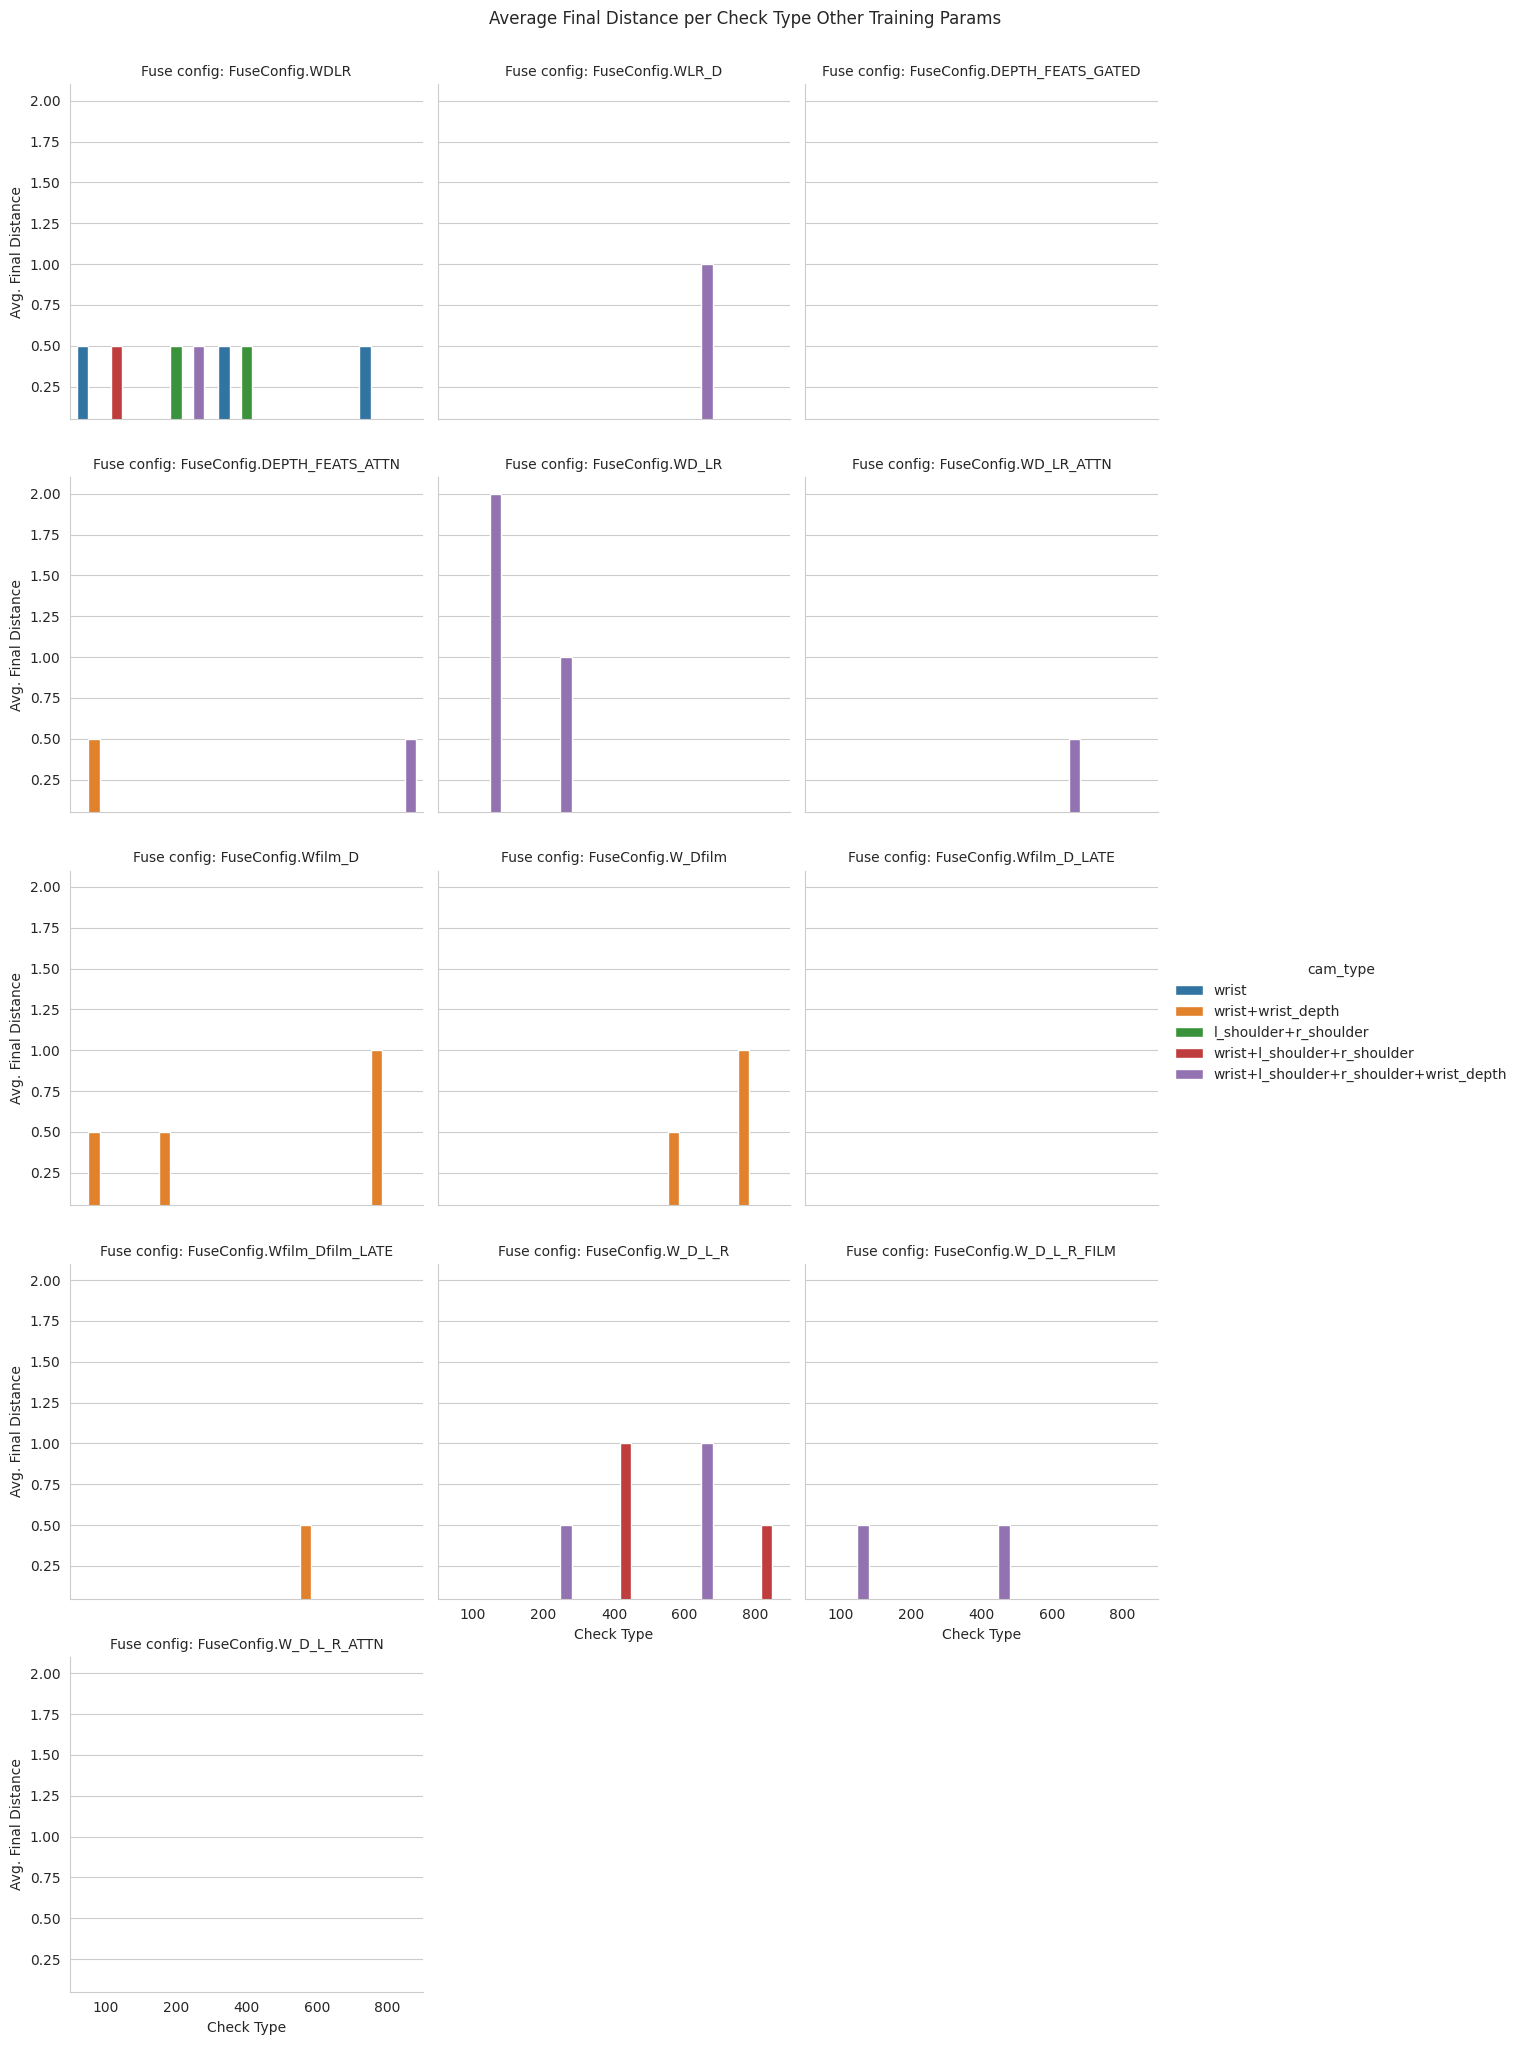

In [21]:
# Plot
g = sns.catplot(
    data=df_avg_dones,
    x='epochs',
    y='done_count',
    hue='cam_type',
    # row="config", 
    col='config',
    col_wrap=3,
    kind="bar",
    errorbar=None,
    # markers=["."] * 10,
    palette="tab10",
    height=4,
    aspect=1,
)

# g.set_titles("Epochs: {row_name}, \n Fuse config: {col_name}")
g.set_titles("Fuse config: {col_name}")
g.set_axis_labels("Check Type", "Avg. Final Distance")
g.set(ylim=(0.05))
g.figure.suptitle("Average Final Distance per Check Type Other Training Params", y=1.02)#
# savefig(f"cam-comb/reach-obs/Z-ro_random-success.png", g = g)
plt.show()


## Baseline


### small then normal only one seed

In [ ]:
configs = [
    FuseConfig.WDLR,
    FuseConfig.WLR_D,
    FuseConfig.DEPTH_FEATS_GATED,
    FuseConfig.DEPTH_FEATS_ATTN,
    FuseConfig.WD_LR,
    FuseConfig.WD_LR_ATTN,
    FuseConfig.Wfilm_D,
    FuseConfig.W_Dfilm,
    # FuseConfig.Wfilm_Dfilm,
    FuseConfig.Wfilm_D_LATE,
    # FuseConfig.W_Dfilm_LATE,
    FuseConfig.Wfilm_Dfilm_LATE,
    FuseConfig.W_D_L_R,
    FuseConfig.W_D_L_R_FILM,
    FuseConfig.W_D_L_R_ATTN,
  ]

# combine_multi_file_seed(
#   configs,
#   "ZZ-lstm-run-small-first",
#   "vs_random-sn",
#   "{file}-cfg:{fuse_config}-seed{seed}", 
#   seeds = [3790]
# )

rnn_all = pd.read_csv("ZZ-lstm-run-small-first/ALLvs_random-sn.csv")
rnn_avg = pd.read_csv("ZZ-lstm-run-small-first/vs_random-sn.csv")

df_avg_long_final, df_avg_long_min = final_and_min_melter(comp_avg)
df_avg_dones = done_count_melter(comp_avg)

df_all_long_final, df_all_long_min = all_final_and_min_melter(comp_all)
df_all_dones = all_done_count_melter(comp_all)


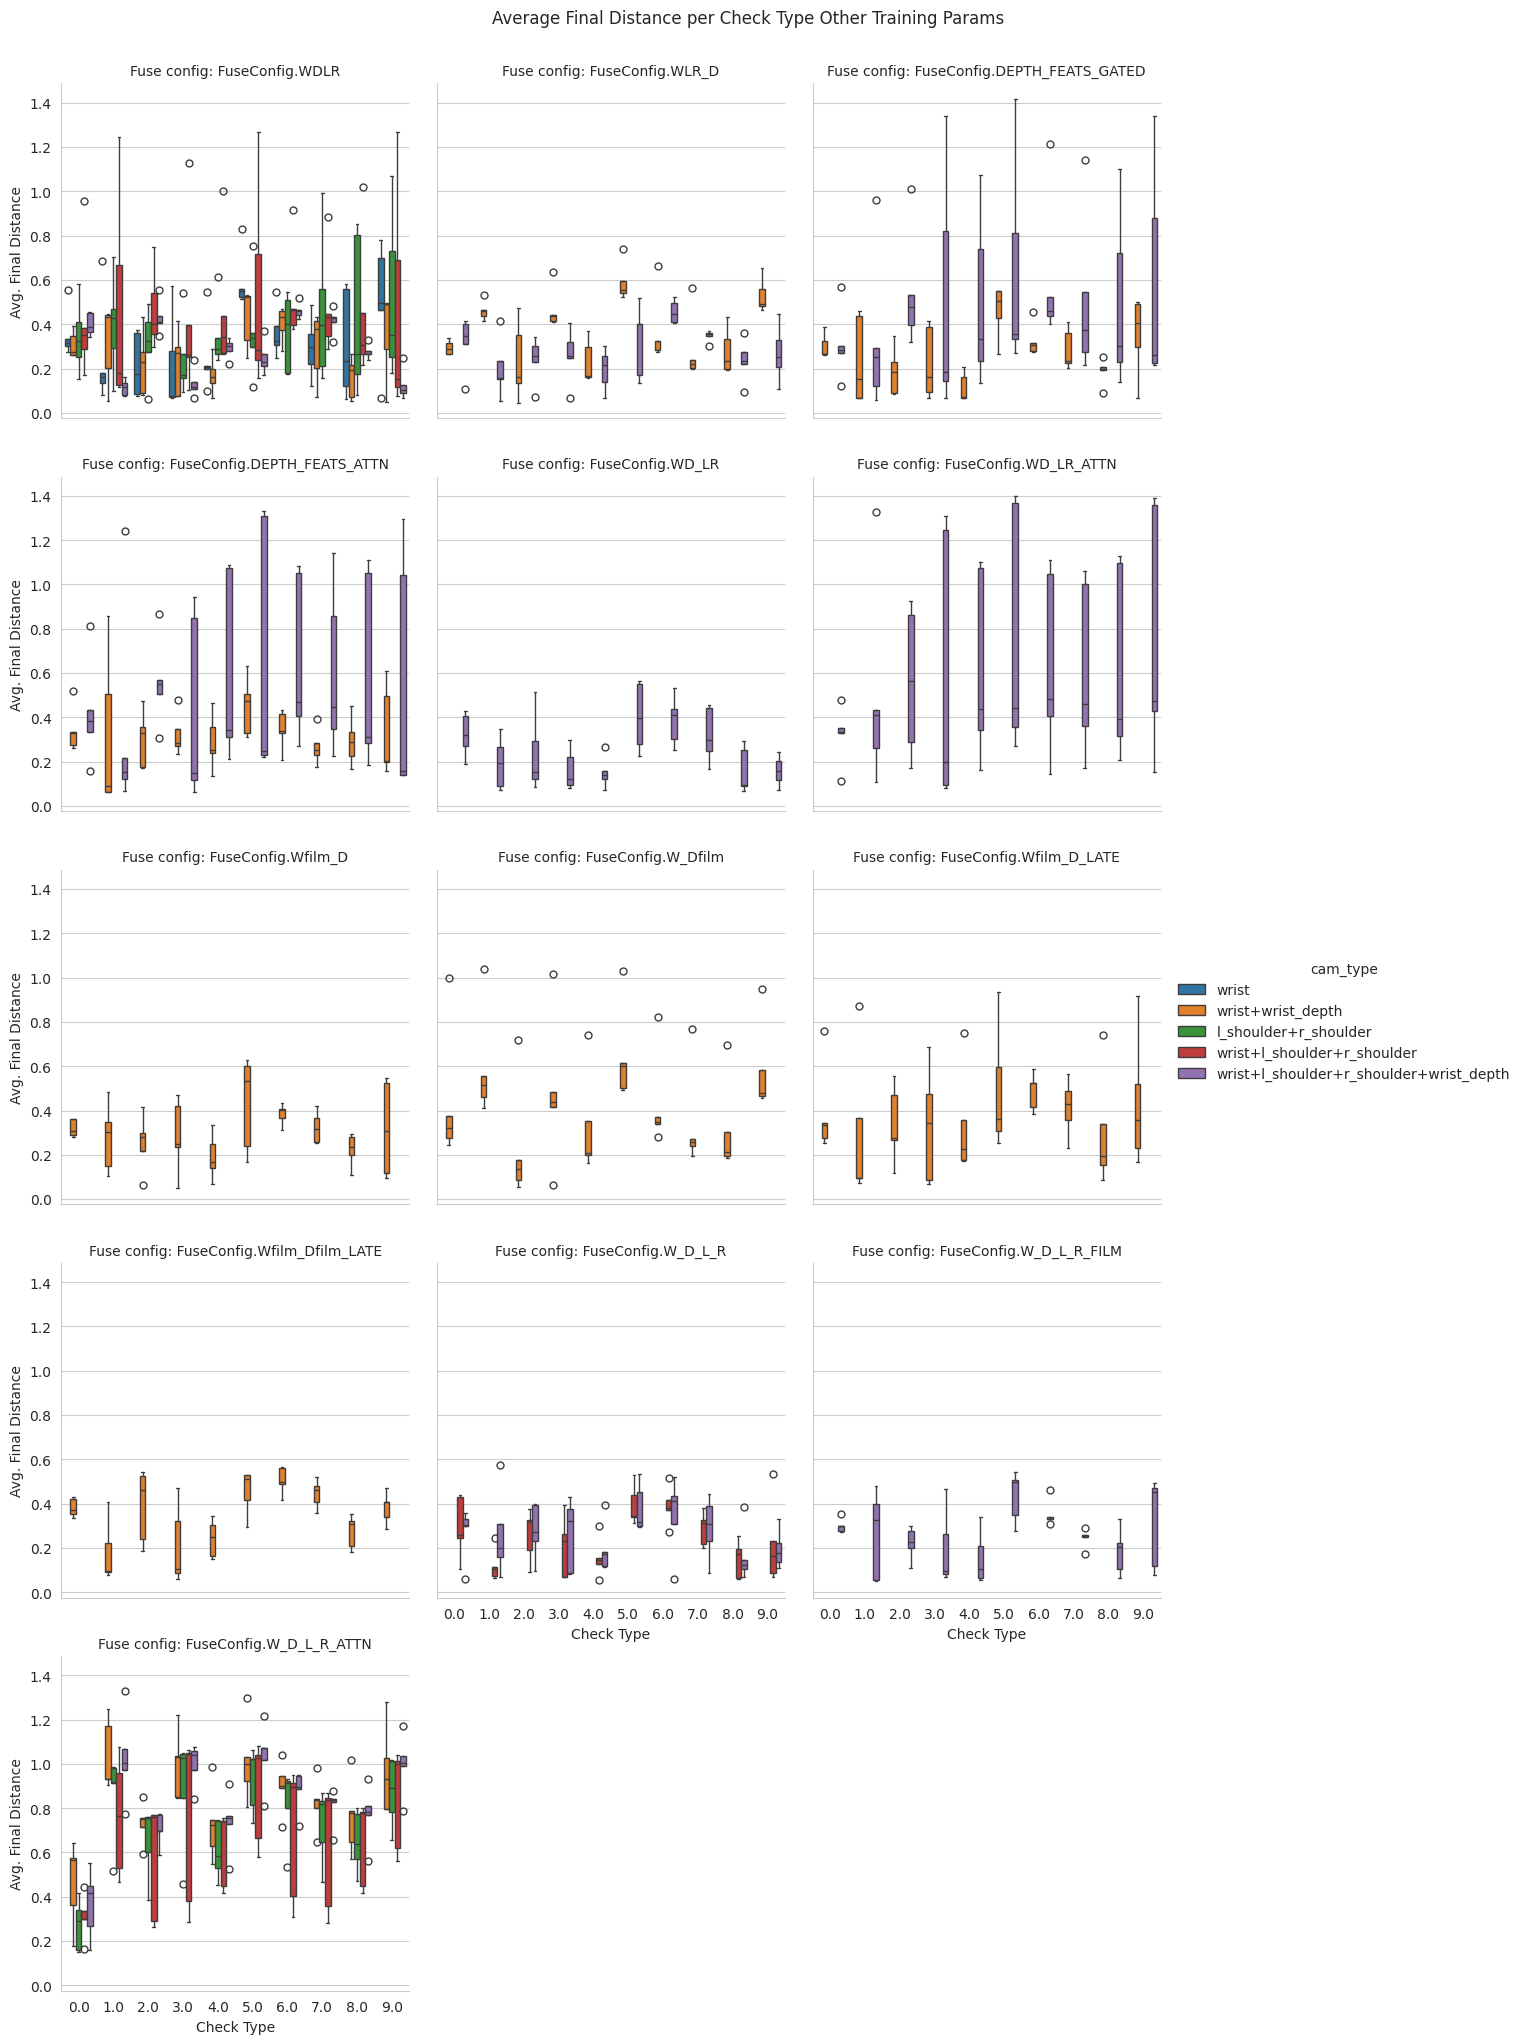

In [19]:
# Plot
g = sns.catplot(
    data=df_all_long_final[df_all_long_final["condition"].str.contains("control")],
    x='demo_idx',
    y='distance',
    hue='cam_type',
    # row="config", 
    col='config',
    col_wrap=3,
    kind="box",
    errorbar=None,
    # markers=["."] * 10,
    palette="tab10",
    height=4,
    aspect=1,
)

# g.set_titles("Epochs: {row_name}, \n Fuse config: {col_name}")
g.set_titles("Fuse config: {col_name}")
g.set_axis_labels("Check Type", "Avg. Final Distance")
g.figure.suptitle("Average Final Distance per Check Type Other Training Params", y=1.02)#
# savefig(f"cam-comb/reach-obs/Z-ro_random-success.png", g = g)
plt.show()


# Fusing Reach


In [468]:
def melty(df):
  long = df.melt(
        id_vars=['epochs', 'cam_type', 'config', 'seed'],
        value_vars=[
          'avg_final_distance',
          'avg_min_distance',
        ],
        var_name='condition',
        value_name='distance'
    )
  long["condition"] = long["condition"].map({
      'avg_final_distance': "Final Distance",
      'avg_min_distance': "Minimum Distance"
    
  })
  return long


configs = [
  FuseConfig.WDLR,
  FuseConfig.WLR_D,
  FuseConfig.DEPTH_FEATS_GATED,
  FuseConfig.DEPTH_FEATS_ATTN,
  FuseConfig.WD_LR,
  FuseConfig.WD_LR_ATTN,
  FuseConfig.Wfilm_D,
  FuseConfig.W_Dfilm,
  FuseConfig.Wfilm_Dfilm,
  FuseConfig.Wfilm_D_LATE,
  FuseConfig.W_Dfilm_LATE,
  FuseConfig.Wfilm_Dfilm_LATE,
  FuseConfig.W_D_L_R,
  FuseConfig.W_D_L_R_FILM,
]
seeds = [
  3790,
  1901,
  4248,
  6689,
  7653
]


df_all = pd.read_csv("ZZ-film-ro/ALLro_random-10Jun.csv")
df_avg = pd.read_csv("ZZ-film-ro/ro_random-Jun10.csv")

df2 = pd.read_csv("ZZ-film-ro/ALLro_random.csv")
df2_avg = pd.read_csv("ZZ-film-ro/ro_random.csv")

df_all = pd.concat([df_all, df2], ignore_index=True)
df_avg = pd.concat([df_avg, df2_avg], ignore_index=True)


## Baseline

In [469]:
df_base = df_avg[df_avg["config"] == f"{FuseConfig.WDLR}"]

df_base_long = melty(df_base)
df_base["done_pct"] = df_base["done_count"].apply(lambda x: x * 10)

/tmp/ipykernel_5659/3980085637.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_base["done_pct"] = df_base["done_count"].apply(lambda x: x * 10)


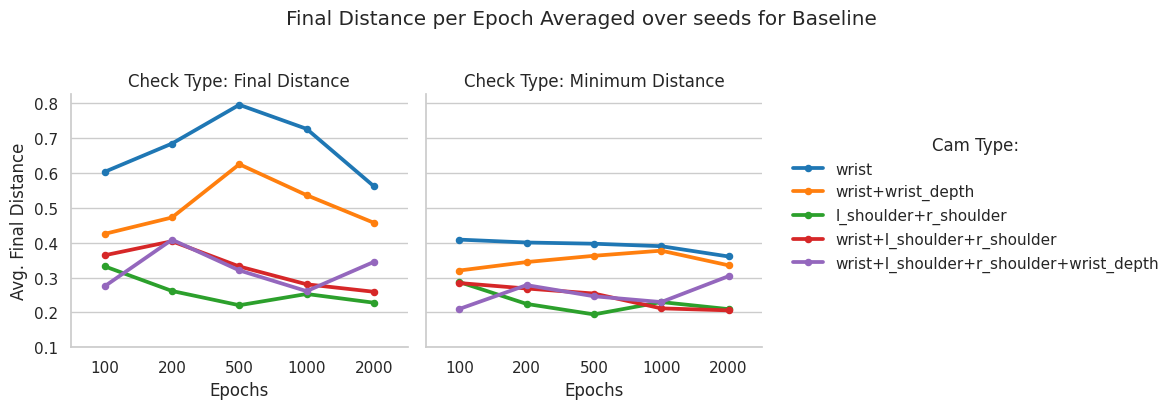

In [470]:
sns.set_theme(style='whitegrid', palette='Set1')
g = sns.catplot(
    data=df_base_long,
    x='epochs',
    y='distance',
    hue='cam_type',
    col='condition',
    # row='seed',
    col_wrap=2,
    kind="point",
    errorbar=None,
    markers=["."] * 10,
    palette="tab10",
    height=4,
    aspect=1,
    # legend = None
)

g.set_titles("Check Type: {col_name}")
g.set_axis_labels("Epochs", "Avg. Final Distance")
g.figure.suptitle("Final Distance per Epoch Averaged over seeds for Baseline", y=1.02)#
g.set(ylim=(0.1))
g._legend.set_title("Cam Type:")
savefig(f"evaluation/baseline/base-reach-dists.png", g = g)
plt.show(g)


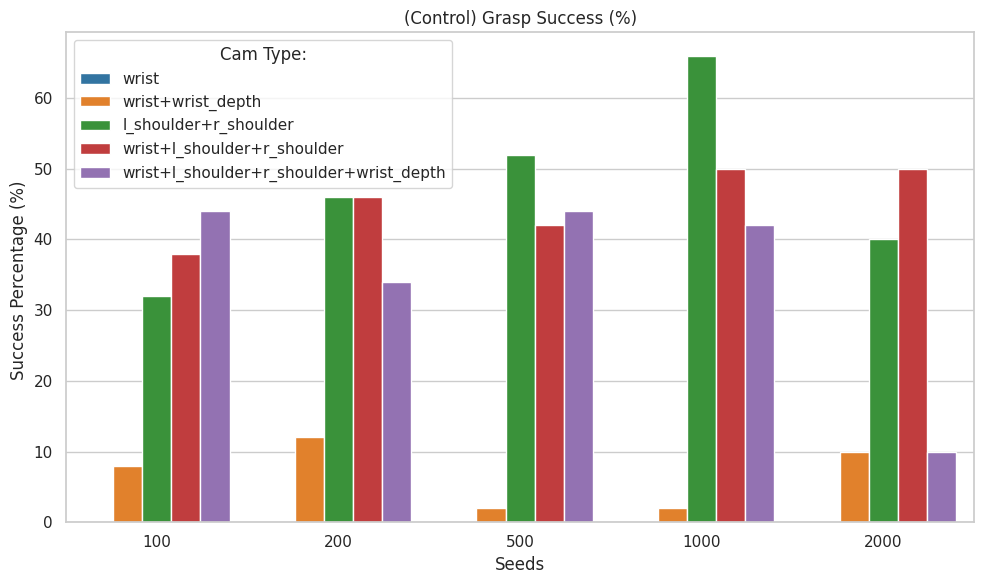

In [471]:
sns.set_theme(style='whitegrid', palette='Set1')
plt.figure(figsize=(10, 6))
sns.set_theme(style='whitegrid', palette='Set1')
sns.barplot(data=df_base, y='done_pct', x="epochs", hue='cam_type', palette='tab10', errorbar=None)
plt.title(f'(Control) Grasp Success (%)')
plt.ylabel('Success Percentage (%) ')
plt.legend(title="Cam Type:")
plt.xlabel('Seeds')
savefig(f"evaluation/baseline/base-reach-success-cams-epochs.png")
plt.show()


## sepdep

In [472]:
configs = [
  FuseConfig.WDLR, ## baseline
  FuseConfig.WLR_D,
  FuseConfig.DEPTH_FEATS_GATED,
  FuseConfig.DEPTH_FEATS_ATTN,
  FuseConfig.WD_LR,
  FuseConfig.WD_LR_ATTN,
]

cams = [
  "wrist+wrist_depth", 
  "wrist+l_shoulder+r_shoulder+wrist_depth"
]

sepdep_avg = df_avg[df_avg["config"].isin(map(str, configs)) 
                    & df_avg["cam_type"].isin(cams)]
sepdep_avg["done_pct"] = sepdep_avg["done_count"].apply(lambda x: x * 10)

/tmp/ipykernel_5659/2534865566.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sepdep_avg["done_pct"] = sepdep_avg["done_count"].apply(lambda x: x * 10)


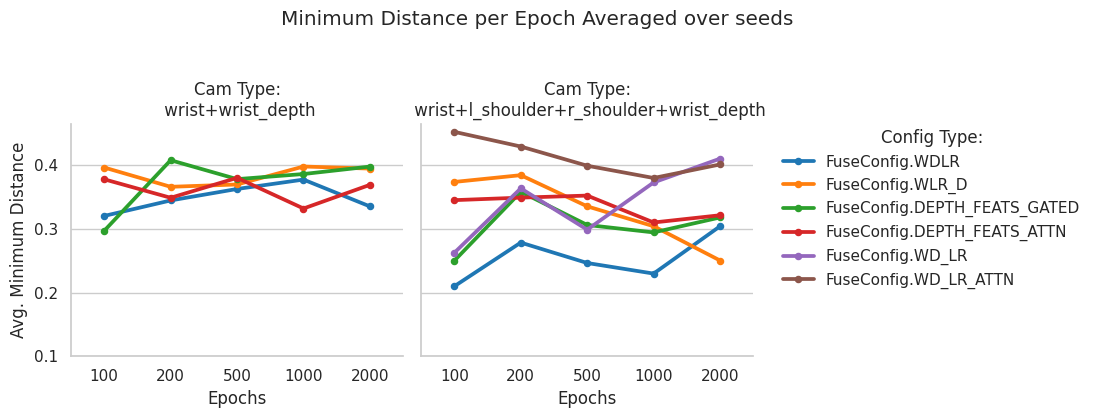

In [473]:
sns.set_theme(style='whitegrid', palette='Set1')

sepdep_long = melty(sepdep_avg)

g = sns.catplot(
    data=sepdep_long[sepdep_long["condition"].str.contains("Min")],
    x='epochs',
    y='distance',
    hue='config',
    col='cam_type',
    # row='cam_type',
    col_wrap=2,
    kind="point",
    errorbar=None,
    markers=["."] * 10,
    palette="tab10",
    height=4,
    aspect=1,
    # legend = None
)
g.figure.subplots_adjust(hspace=0.2, wspace=0.2)
g.set_titles("Cam Type:\n {col_name}")
g.set_axis_labels("Epochs", "Avg. Minimum Distance")
g.figure.suptitle("Minimum Distance per Epoch Averaged over seeds", y=1.04)#
g.set(ylim=(0.1))
g._legend.set_title("Config Type:")
savefig(f"evaluation/sep-dep/Z-reach-min-cams.png", g = g)
plt.show(g)
##TODO: add the 400 epochs runing now 'ALLvs_random-ns-sepdeps-400eps.csv'

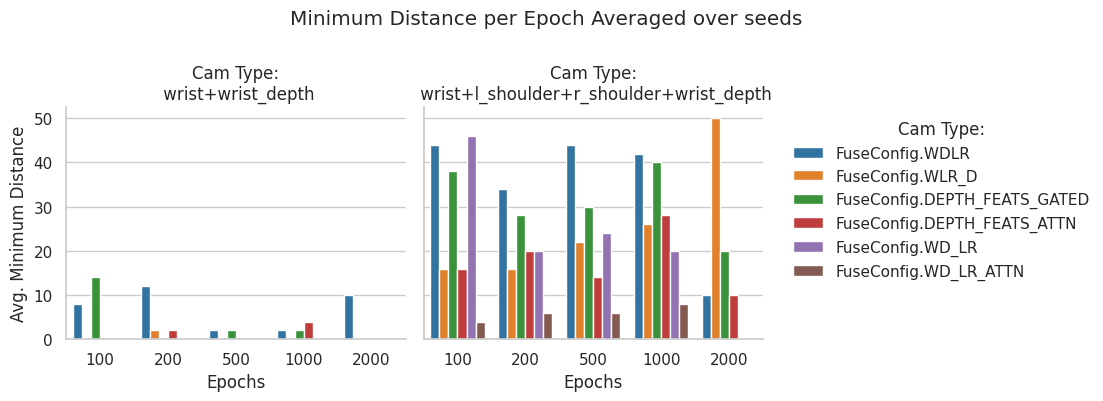

In [474]:
g = sns.catplot(
    data=sepdep_avg,
    x='epochs',
    y='done_pct',
    hue='config',
    col='cam_type',
    # row='cam_type',
    col_wrap=2,
    kind="bar",
    errorbar=None,
    palette="tab10",
    height=4,
    aspect=1,
    # legend = None
)
# g.figure.subplots_adjust(hspace=0.2, wspace=0.2)
g.set_titles("Cam Type:\n {col_name}")
g.set_axis_labels("Epochs", "Avg. Minimum Distance")
g.figure.suptitle("Minimum Distance per Epoch Averaged over seeds", y=1.0)#
g._legend.set_title("Cam Type:")
savefig(f"evaluation/sep-dep/reach-success-cams-epochs.png", g=g)
plt.show(g)


## Films


In [475]:
configs = [
  FuseConfig.WDLR,
  FuseConfig.Wfilm_D,
  FuseConfig.Wfilm_D,
  FuseConfig.W_Dfilm,
  FuseConfig.Wfilm_Dfilm,
  FuseConfig.Wfilm_D_LATE,
  FuseConfig.W_Dfilm_LATE,
  FuseConfig.Wfilm_Dfilm_LATE,
]

cams = [
  "wrist+wrist_depth", 
]

film_avg = df_avg[df_avg["config"].isin(map(str, configs)) 
                    & df_avg["cam_type"].isin(cams)]
film_avg["done_pct"] = film_avg["done_count"].apply(lambda x: x * 10)

/tmp/ipykernel_5659/3821330407.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  film_avg["done_pct"] = film_avg["done_count"].apply(lambda x: x * 10)


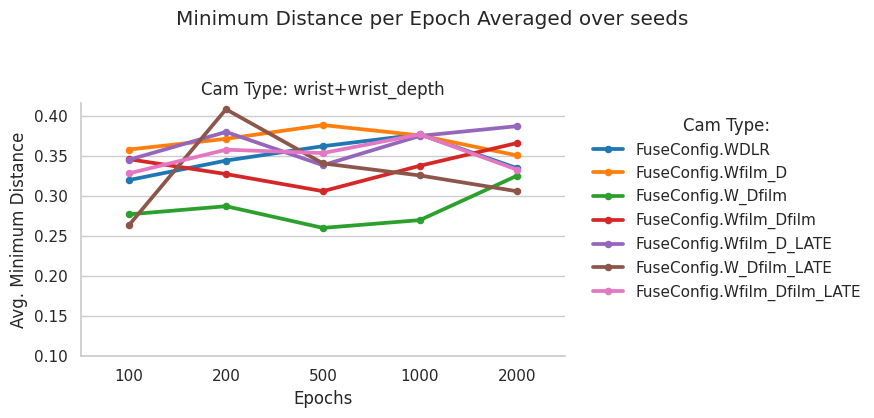

In [476]:
sns.set_theme(style='whitegrid', palette='Set1')

film_long = melty(film_avg)

g = sns.catplot(
    data=film_long[film_long["condition"].str.contains("Min")],
    x='epochs',
    y='distance',
    hue='config',
    col='condition',
    row='cam_type',
    # col_wrap=2,
    kind="point",
    errorbar=None,
    markers=["."] * 10,
    palette="tab10",
    height=4,
    aspect=1.5
    # legend = None
)
g.figure.subplots_adjust(hspace=0.2, wspace=0.2)
g.set_titles("Cam Type: {row_name}")
g.set_axis_labels("Epochs", "Avg. Minimum Distance")
g.figure.suptitle("Minimum Distance per Epoch Averaged over seeds", y=1.04)#
g.set(ylim=(0.1))
g._legend.set_title("Cam Type:")
savefig(f"evaluation/film/reach-min-cams.png", g = g)
plt.show(g)
##TODO: add the 400 epochs runing now 'ALLvs_random-ns-sepdeps-400eps.csv'

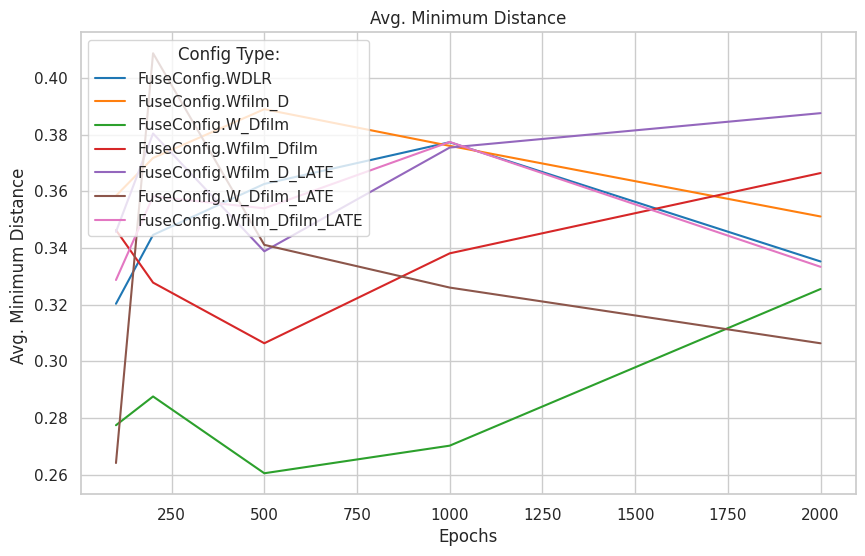

In [ ]:
# sns.set_theme(style='whitegrid', palette='Set1')
# plt.figure(figsize=(10, 6))
# sns.set_theme(style='whitegrid', palette='Set1')
# sns.lineplot(data=film_long[film_long["condition"].str.contains("Min")], y='distance', x="epochs", hue='config', palette='tab10', errorbar=None)
# plt.title(f'Avg. Minimum Distance')
# plt.ylabel('Avg. Minimum Distance ')
# plt.legend(title="Config Type:", loc="upper left")
# plt.xlabel('Epochs')
# # savefig(f"evaluation/film/reach-min-cams.png", g = g)

# plt.show()

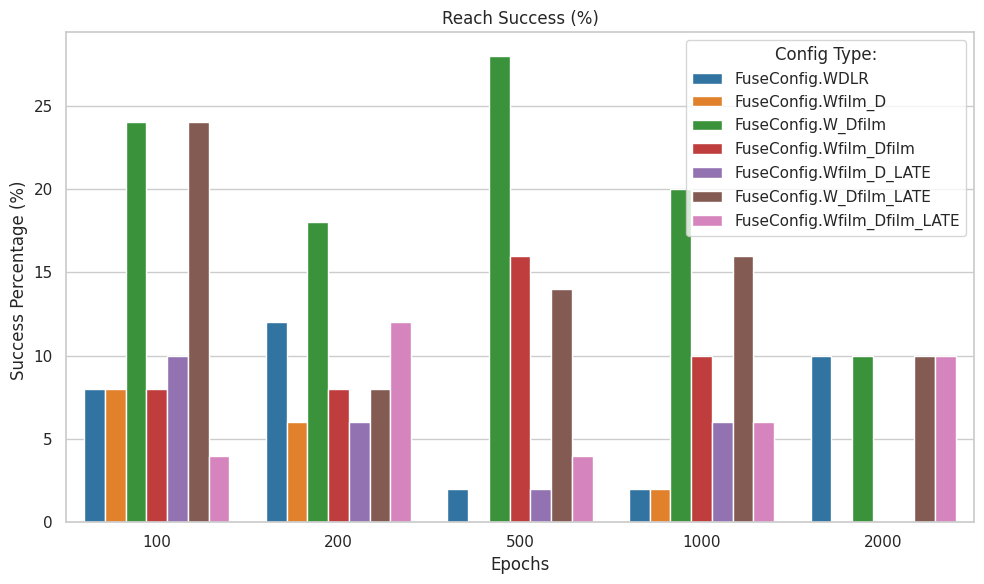

In [477]:
sns.set_theme(style='whitegrid', palette='Set1')
plt.figure(figsize=(10, 6))
sns.set_theme(style='whitegrid', palette='Set1')
sns.barplot(data=film_avg, y='done_pct', x="epochs", hue='config', palette='tab10', errorbar=None)
plt.title(f'Reach Success (%)')
plt.ylabel('Success Percentage (%) ')
plt.legend(title="Config Type:")
plt.xlabel('Epochs')
savefig(f"evaluation/film/base-reach-success-config-epochs.png")
plt.show()


## Derivatives

In [484]:
configs = [
  FuseConfig.WDLR,
  FuseConfig.W_D_L_R,
  FuseConfig.W_D_L_R_FILM,
  FuseConfig.W_D_L_R_ATTN,
]

cams = [
  "wrist+l_shoulder+r_shoulder+wrist_depth",
  "wrist+l_shoulder+r_shoulder"
]
ds = df_avg[
  df_avg["config"].isin(map(str, configs)) 
  & df_avg["cam_type"].isin(cams)
]
ds["done_pct"] = ds["done_count"].apply(lambda x: x * 10)

ds_long = melty(ds)

/tmp/ipykernel_5659/962761244.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ds["done_pct"] = ds["done_count"].apply(lambda x: x * 10)


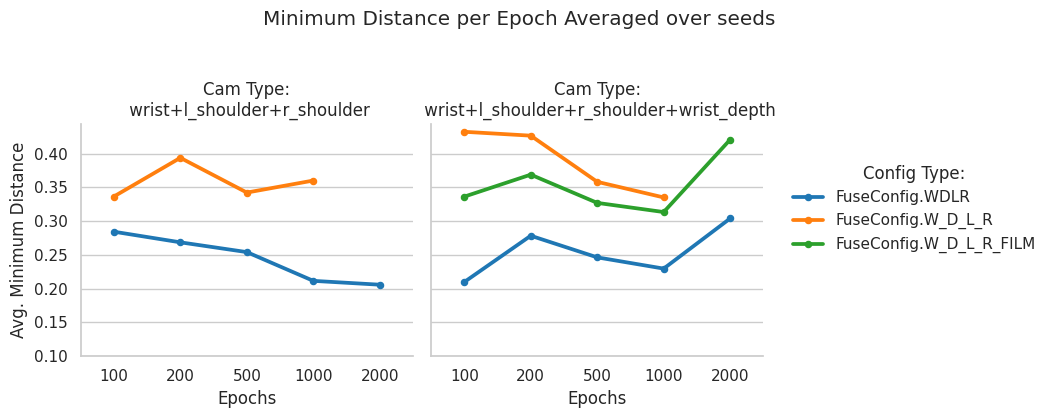

In [485]:
sns.set_theme(style='whitegrid', palette='Set1')


g = sns.catplot(
    data=ds_long[ds_long["condition"].str.contains("Min")],
    x='epochs',
    y='distance',
    hue='config',
    col='cam_type',
    # row='cam_type',
    col_wrap=2,
    kind="point",
    errorbar=None,
    markers=["."] * 10,
    palette="tab10",
    height=4,
    aspect=1,
    # legend = None
)
g.figure.subplots_adjust(hspace=0.2, wspace=0.2)
g.set_titles("Cam Type:\n {col_name}")
g.set_axis_labels("Epochs", "Avg. Minimum Distance")
g.figure.suptitle("Minimum Distance per Epoch Averaged over seeds", y=1.04)#
g.set(ylim=(0.1))
g._legend.set_title("Config Type:")
savefig(f"evaluation/derivatives/Z-reach-min-cams.png", g = g)
plt.show(g)
##TODO: add the 400 epochs runing now 'ALLvs_random-ns-sepdeps-400eps.csv'

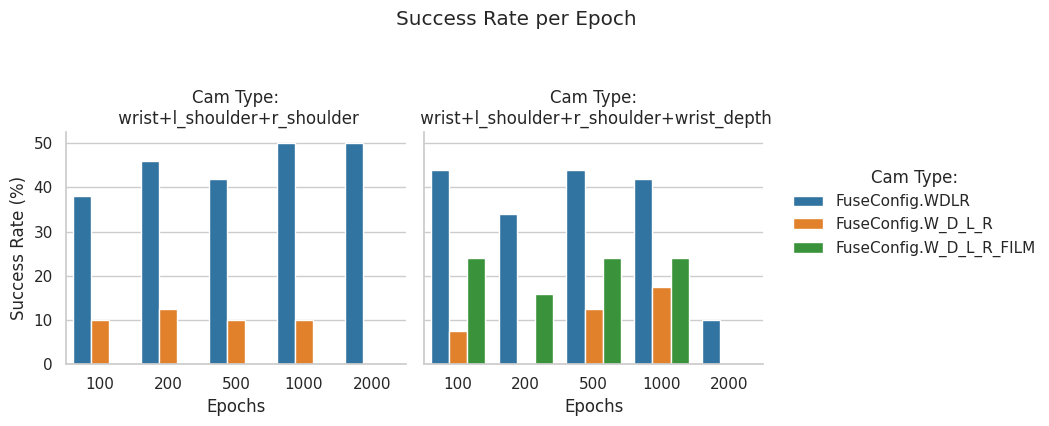

In [486]:
g = sns.catplot(
    data=ds,
    x='epochs',
    y='done_pct',
    hue='config',
    col='cam_type',
    # row='cam_type',
    col_wrap=2,
    kind="bar",
    errorbar=None,
    palette="tab10",
    height=4,
    aspect=1,
    # legend = None
)
# g.figure.subplots_adjust(hspace=0.2, wspace=0.2)
g.set_titles("Cam Type:\n {col_name}")
g.set_axis_labels("Epochs", "Success Rate (%)")
g.figure.suptitle("Success Rate per Epoch ", y=1.06)#
g._legend.set_title("Cam Type:")
savefig(f"evaluation/derivatives/Z-reach-success-cams.png", g=g)
plt.show(g)
